# Neuro-Symbolic CeNN / QELM Functional-Emulation Benchmark for QML-TSF

This notebook implements a robust publication-oriented benchmark with:

- **6 real datasets only**: Energy, AAPL, Jena Climate, ETTh1, ETTm2, Exchange Rate.
- **No generated or fallback synthetic data**: every dataset is downloaded or located from Kaggle/GitHub.
- **10 models**: Persistence, Moving Average, MLP, LSTM, Transformer, N-HiTS, N-BEATS, QELM, CeNN_NS, CeNN_Emulator.
- **2 stages**: `smoke` for a fast pipeline test, then `full` for publication-level experiments.
- **Leakage-safe preprocessing**: chronological split, scaler fitted on train only.
- **Comprehensive metrics**: MAE, RMSE, MSE, R2, MAPE, sMAPE, WAPE, MASE, RMSSE, MdAE, P90AE, bias, directional accuracy, training time, inference latency, parameter count, and emulation-fidelity metrics.

Scientific scope: the CeNN models are evaluated as **classical functional emulators** of selected QELM-related behaviors, not as quantum computers and not as quantum-state simulators.


In [1]:
# ================================================================
# CELL 0 - Global configuration
# ================================================================

RUN_MODE = "full"  # Change to "full" only after smoke mode passes end-to-end.
FORCE_REDOWNLOAD = False
SAVE_INTERMEDIATE_PREDICTIONS = True

# Main benchmark protocol.
WINDOW = 48
HORIZON = 24
SPLIT_RATIOS = (0.70, 0.15, 0.15)

# Smoke mode is intentionally small. Full mode is the publication run.
PROFILES = {
    "smoke": {
        "max_points": 2500,
        "seeds": [42],
        "epochs": 2,
        "patience": 1,
        "batch_size": 128,
        "hidden_dim": 32,
        "n_cells": 32,
        "qelm_features": 128,
        "emul_dim": 16,
        "train_window_limit": 1200,
        "num_workers": 0,
    },
    "full": {
        "max_points": 20000,
        "seeds": [42, 123, 2024, 7, 99],
        "epochs": 60,
        "patience": 10,
        "batch_size": 256,
        "hidden_dim": 128,
        "n_cells": 128,
        "qelm_features": 512,
        "emul_dim": 32,
        "train_window_limit": None,
        "num_workers": 0,
    },
}

assert RUN_MODE in PROFILES, "RUN_MODE must be either 'smoke' or 'full'."
CFG = PROFILES[RUN_MODE]

from pathlib import Path
RUN_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
DATA_ROOT = RUN_ROOT / "data" / "raw"
OUTPUT_ROOT = RUN_ROOT / "outputs" / f"{RUN_MODE}_run"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
PRED_ROOT = OUTPUT_ROOT / "predictions"

for p in [DATA_ROOT, OUTPUT_ROOT, FIGURE_ROOT, PRED_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print(f"RUN_MODE = {RUN_MODE}")
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")
print(CFG)


RUN_MODE = full
DATA_ROOT = /kaggle/working/data/raw
OUTPUT_ROOT = /kaggle/working/outputs/full_run
{'max_points': 20000, 'seeds': [42, 123, 2024, 7, 99], 'epochs': 60, 'patience': 10, 'batch_size': 256, 'hidden_dim': 128, 'n_cells': 128, 'qelm_features': 512, 'emul_dim': 32, 'train_window_limit': None, 'num_workers': 0}


In [2]:
# ================================================================
# CELL 1 - Optional dependency installation
# ================================================================

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "torch": "torch",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "requests": "requests",
    "tqdm": "tqdm",
    "kagglehub": "kagglehub",
}

def ensure_package(import_name: str, pip_name: str):
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for import_name, pip_name in REQUIRED_PACKAGES.items():
    ensure_package(import_name, pip_name)

print("Dependency check completed.")


Dependency check completed.


In [3]:
# ================================================================
# CELL 2 - Imports, reproducibility, and device setup
# ================================================================

import os, re, math, time, json, zipfile, gzip, shutil, random, warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.special import softmax

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)


Device: cuda
GPU: Tesla T4


## 1. Dataset sources

The notebook first checks whether each dataset already exists in `/kaggle/input` or `data/raw`. If not found, it attempts to download from **Kaggle first**, then from **GitHub** when a stable raw GitHub source is available. It never creates synthetic fallback data.

Primary datasets:

| Dataset | Primary source type | Target used |
|---|---|---|
| Energy | Kaggle hourly energy consumption / GitHub PJM mirror | PJME_MW |
| AAPL | Kaggle AAPL stock data / GitHub Plotly mirror | log-return of adjusted/close price |
| Jena | Kaggle Jena Climate | T (degC) |
| ETTh1 | Kaggle ETDataset / GitHub ETDataset | OT |
| ETTm2 | Kaggle ETDataset / GitHub ETDataset | OT |
| Exchange Rate | Kaggle long-horizon/time-series or GitHub benchmark | first/selected exchange-rate column |


In [4]:
# ================================================================
# CELL 3 - Dataset registry and download utilities
# ================================================================

DATASET_REGISTRY = {
    "Energy": {
        "kaggle_slugs": ["robikscube/hourly-energy-consumption"],
        "github_urls": ["https://raw.githubusercontent.com/robikscube/hourly-energy-consumption/master/PJME_hourly.csv"],
        "file_hints": ["PJME_hourly.csv", "PJMW_hourly.csv"],
        "target_candidates": ["PJME_MW", "PJMW_MW", "MW", "value"],
        "date_candidates": ["Datetime", "datetime", "date", "Date"],
        "transform": "identity",
    },
    "AAPL": {
        "kaggle_slugs": [
            "tarunpaparaju/apple-aapl-historical-stock-data",
            "varpit94/apple-stock-data-updated-till-22jun2021",
            "iamtanmayshukla/apple-inc-aapl-stock-data-1980-2024",
        ],
        "github_urls": ["https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"],
        "file_hints": ["AAPL.csv", "aapl.csv", "HistoricalQuotes.csv", "Apple.csv", "finance-charts-apple.csv"],
        "target_candidates": ["Adj Close", "Close", "close", "AAPL.Adjusted", "AAPL.Close", "Close/Last"],
        "date_candidates": ["Date", "date", "datetime"],
        "transform": "log_return",
    },
    "Jena": {
        "kaggle_slugs": ["stytch16/jena-climate-2009-2016", "mnassrib/jena-climate"],
        "github_urls": [],
        "file_hints": ["jena_climate_2009_2016.csv", "jena_climate.csv"],
        "target_candidates": ["T (degC)", "T_degC", "temperature", "Temperature"],
        "date_candidates": ["Date Time", "datetime", "date"],
        "transform": "identity",
    },
    "ETTh1": {
        "kaggle_slugs": ["tarit21/electricity-transformer-dataset-etdataset", "labbaxmx/time-series"],
        "github_urls": ["https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"],
        "file_hints": ["ETTh1.csv"],
        "target_candidates": ["OT", "oil_temperature"],
        "date_candidates": ["date", "Date", "datetime"],
        "transform": "identity",
    },
    "ETTm2": {
        "kaggle_slugs": ["tarit21/electricity-transformer-dataset-etdataset", "labbaxmx/time-series"],
        "github_urls": ["https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv"],
        "file_hints": ["ETTm2.csv"],
        "target_candidates": ["OT", "oil_temperature"],
        "date_candidates": ["date", "Date", "datetime"],
        "transform": "identity",
    },
    "ExchangeRate": {
        "kaggle_slugs": ["labbaxmx/time-series", "giochelavaipiatti/time-series-forecasts-popular-benchmark-datasets"],
        "github_urls": [
            "https://raw.githubusercontent.com/laiguokun/multivariate-time-series-data/master/exchange_rate/exchange_rate.txt",
            "https://raw.githubusercontent.com/thuml/Time-Series-Library/main/dataset/exchange_rate/exchange_rate.csv",
        ],
        "file_hints": ["exchange_rate.csv", "exchange_rate.txt", "exchange_rate"],
        "target_candidates": ["OT", "0", "USD", "exchange_rate"],
        "date_candidates": ["date", "Date", "datetime"],
        "transform": "identity",
    },
}

LOCAL_SEARCH_ROOTS = [DATA_ROOT]
if Path("/kaggle/input").exists():
    LOCAL_SEARCH_ROOTS.insert(0, Path("/kaggle/input"))

def normalize_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).lower())

def find_file_by_hints(root: Path, hints: List[str]) -> Optional[Path]:
    if not root.exists():
        return None
    all_files = [p for p in root.rglob("*") if p.is_file()]
    normalized_hints = [normalize_name(h) for h in hints]
    for hint in hints:
        matches = [p for p in all_files if p.name == hint]
        if matches:
            return matches[0]
    for hnorm in normalized_hints:
        matches = [p for p in all_files if hnorm in normalize_name(p.name)]
        if matches:
            return sorted(matches, key=lambda p: len(str(p)))[0]
    return None

def download_url(url: str, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = url.split("/")[-1].split("?")[0] or "downloaded_file"
    out_path = out_dir / fname
    if out_path.exists() and not FORCE_REDOWNLOAD:
        return out_path
    print(f"Downloading GitHub/raw URL: {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    out_path.write_bytes(r.content)
    return out_path

def extract_if_needed(path: Path) -> Path:
    if path.suffix.lower() == ".zip":
        out_dir = path.with_suffix("")
        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(path, "r") as zf:
            zf.extractall(out_dir)
        return out_dir
    return path

def locate_or_download_dataset(name: str, spec: Dict[str, Any]) -> Path:
    # 1) Already available locally / Kaggle input.
    for root in LOCAL_SEARCH_ROOTS:
        found = find_file_by_hints(root, spec["file_hints"])
        if found is not None:
            print(f"[{name}] found locally: {found}")
            return found

    # 2) Kaggle dataset download through kagglehub.
    try:
        import kagglehub
        for slug in spec.get("kaggle_slugs", []):
            try:
                print(f"[{name}] trying Kaggle dataset: {slug}")
                downloaded = Path(kagglehub.dataset_download(slug, force_download=FORCE_REDOWNLOAD))
                found = find_file_by_hints(downloaded, spec["file_hints"])
                if found is not None:
                    print(f"[{name}] downloaded from Kaggle: {found}")
                    return found
                else:
                    print(f"[{name}] Kaggle slug downloaded, but expected file was not found in {downloaded}")
            except Exception as e:
                print(f"[{name}] Kaggle failed for {slug}: {type(e).__name__}: {e}")
    except Exception as e:
        print(f"[{name}] kagglehub unavailable: {type(e).__name__}: {e}")

    # 3) GitHub/raw fallback when available.
    for url in spec.get("github_urls", []):
        try:
            out = download_url(url, DATA_ROOT / name)
            out = extract_if_needed(out)
            if out.is_dir():
                found = find_file_by_hints(out, spec["file_hints"])
                if found is not None:
                    return found
            return out
        except Exception as e:
            print(f"[{name}] GitHub/raw failed for {url}: {type(e).__name__}: {e}")

    raise RuntimeError(
        f"Could not locate or download dataset '{name}'. "
        "Provide it under /kaggle/input or data/raw, or check Kaggle access. "
        f"Expected hints: {spec['file_hints']}"
    )


In [5]:
# ================================================================
# CELL 4 - Robust dataset loading and target extraction
# ================================================================

@dataclass
class SeriesDataset:
    name: str
    values: np.ndarray
    raw_length: int
    used_length: int
    target_col: str
    source_file: str
    transform: str


def read_table_auto(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".gz":
        return pd.read_csv(path, compression="gzip")
    if suffix in [".csv", ".txt", ".tsv", ""]:
        # Try comma CSV first.
        try:
            df = pd.read_csv(path)
            if df.shape[1] >= 2:
                return df
        except Exception:
            pass
        # Try separator inference.
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            pass
        # Try no-header comma/space-separated matrix.
        for sep in [",", "\t", r"\s+"]:
            try:
                return pd.read_csv(path, header=None, sep=sep, engine="python")
            except Exception:
                continue
    raise ValueError(f"Unsupported or unreadable file: {path}")


def clean_numeric_series(s: pd.Series) -> pd.Series:
    if s.dtype == object:
        s = s.astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
        s = s.str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(s, errors="coerce")


def choose_column(df: pd.DataFrame, candidates: List[str]) -> str:
    columns = list(df.columns)
    # Exact match.
    for cand in candidates:
        for col in columns:
            if str(col) == str(cand):
                return col
    # Normalized match.
    cands_norm = [normalize_name(c) for c in candidates]
    for col in columns:
        if normalize_name(col) in cands_norm:
            return col
    # Contains match.
    for cand_norm in cands_norm:
        for col in columns:
            if cand_norm and cand_norm in normalize_name(col):
                return col
    # Fallback to last numeric column.
    numeric_cols = []
    for col in columns:
        numeric = clean_numeric_series(df[col])
        if numeric.notna().sum() > max(10, len(df) * 0.2):
            numeric_cols.append(col)
    if not numeric_cols:
        raise ValueError(f"No numeric column found. Columns: {columns[:20]}")
    return numeric_cols[-1]


def maybe_sort_by_date(df: pd.DataFrame, date_candidates: List[str]) -> pd.DataFrame:
    for cand in date_candidates:
        if cand in df.columns:
            d = pd.to_datetime(df[cand], errors="coerce")
            if d.notna().sum() > len(df) * 0.5:
                return df.assign(__date__=d).sort_values("__date__").drop(columns="__date__")
    # Normalized search.
    cand_norm = [normalize_name(c) for c in date_candidates]
    for col in df.columns:
        if normalize_name(col) in cand_norm:
            d = pd.to_datetime(df[col], errors="coerce")
            if d.notna().sum() > len(df) * 0.5:
                return df.assign(__date__=d).sort_values("__date__").drop(columns="__date__")
    return df


def load_series_dataset(name: str, max_points: int) -> SeriesDataset:
    spec = DATASET_REGISTRY[name]
    source_file = locate_or_download_dataset(name, spec)
    df = read_table_auto(source_file)
    df = maybe_sort_by_date(df, spec.get("date_candidates", []))

    # If the exchange-rate benchmark is a no-header matrix, use the first column by convention.
    if name == "ExchangeRate" and all(isinstance(c, int) for c in df.columns):
        target_col = df.columns[0]
    else:
        target_col = choose_column(df, spec["target_candidates"])

    values = clean_numeric_series(df[target_col]).dropna().astype(float).to_numpy()
    transform = spec.get("transform", "identity")
    if transform == "log_return":
        values = values[values > 0]
        values = np.diff(np.log(values))
    elif transform == "identity":
        pass
    else:
        raise ValueError(f"Unknown transform: {transform}")

    values = values[np.isfinite(values)]
    raw_length = int(len(values))
    if raw_length < WINDOW + HORIZON + 100:
        raise ValueError(f"Dataset {name} is too short after cleaning: {raw_length}")

    # Use the most recent max_points values for market/operational relevance.
    if max_points is not None and raw_length > max_points:
        values = values[-max_points:]
    used_length = int(len(values))

    return SeriesDataset(
        name=name,
        values=values.astype(np.float32),
        raw_length=raw_length,
        used_length=used_length,
        target_col=str(target_col),
        source_file=str(source_file),
        transform=transform,
    )

DATASET_NAMES = ["Energy", "AAPL", "Jena", "ETTh1", "ETTm2", "ExchangeRate"]
DATASETS = [load_series_dataset(name, CFG["max_points"]) for name in DATASET_NAMES]

# Keep the dataset manifest compact and JSON/CSV-safe.
# Do NOT write the full numeric arrays in the manifest.
def dataset_manifest_row(ds: SeriesDataset) -> dict:
    return {
        "name": ds.name,
        "raw_length": int(ds.raw_length),
        "used_length": int(ds.used_length),
        "target_col": str(ds.target_col),
        "source_file": str(ds.source_file),
        "transform": str(ds.transform),
        "first_value": float(np.asarray(ds.values).reshape(-1)[0]),
        "last_value": float(np.asarray(ds.values).reshape(-1)[-1]),
        "mean": float(np.nanmean(ds.values)),
        "std": float(np.nanstd(ds.values)),
        "min": float(np.nanmin(ds.values)),
        "max": float(np.nanmax(ds.values)),
    }

dataset_manifest = pd.DataFrame([dataset_manifest_row(ds) for ds in DATASETS])
dataset_manifest.to_csv(OUTPUT_ROOT / "dataset_manifest.csv", index=False)
dataset_manifest


[Energy] found locally: /kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
[AAPL] found locally: /kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv
[Jena] found locally: /kaggle/input/datasets/stytch16/jena-climate-2009-2016/jena_climate_2009_2016.csv
[ETTh1] found locally: /kaggle/input/datasets/labbaxmx/time-series/datasets/ETTh1.csv
[ETTm2] found locally: /kaggle/input/datasets/labbaxmx/time-series/datasets/ETTm2.csv
[ExchangeRate] found locally: /kaggle/input/datasets/labbaxmx/time-series/datasets/exchange_rate.csv


,name,raw_length,used_length,target_col,source_file,transform,first_value,last_value,mean,std,min,max
0,Energy,145366,20000,PJME_MW,/kaggle/input/datasets/robikscube/hourly-energ...,identity,28637.00000,35486.000000,31274.326172,6554.373535,19255.000000,56609.000000
1,AAPL,2517,2517,Close/Last,/kaggle/input/datasets/tarunpaparaju/apple-aap...,log_return,-0.00067,-0.000585,0.000880,0.016292,-0.131876,0.085022
2,Jena,420551,20000,T (degC),/kaggle/input/datasets/stytch16/jena-climate-2...,identity,11.97000,-4.820000,9.603914,8.251534,-8.550000,34.340000
3,ETTh1,17420,17420,OT,/kaggle/input/datasets/labbaxmx/time-series/da...,identity,30.53100,9.567000,13.324672,8.566700,-4.080000,46.007000
4,ETTm2,69680,20000,OT,/kaggle/input/datasets/labbaxmx/time-series/da...,identity,14.05300,45.327000,21.605358,11.590486,-2.646500,50.844501
5,ExchangeRate,7588,7588,OT,/kaggle/input/datasets/labbaxmx/time-series/da...,identity,0.59300,0.692689,0.654418,0.115284,0.393153,0.882379


## 2. Chronological splits and leakage-safe preprocessing

The raw series is split chronologically. The scaler is fitted only on the training segment. Validation and test values are transformed with the train scaler. Supervised windows are assigned to train/validation/test according to the **forecast endpoint**, preventing leakage from future targets.


In [6]:
# ================================================================
# CELL 5 - Windowing, train-only scaling, and metrics
# ================================================================

@dataclass
class PreparedData:
    name: str
    train_x: np.ndarray
    train_y: np.ndarray
    val_x: np.ndarray
    val_y: np.ndarray
    test_x: np.ndarray
    test_y: np.ndarray
    train_y_raw: np.ndarray
    val_y_raw: np.ndarray
    test_y_raw: np.ndarray
    train_raw: np.ndarray
    scaler_mean: float
    scaler_scale: float
    positive_domain: bool


def make_windows(values_scaled: np.ndarray, values_raw: np.ndarray, window: int, horizon: int):
    xs, ys, ys_raw, endpoints = [], [], [], []
    n = len(values_scaled)
    for start in range(0, n - window - horizon + 1):
        x = values_scaled[start:start+window]
        y = values_scaled[start+window:start+window+horizon]
        yr = values_raw[start+window:start+window+horizon]
        xs.append(x)
        ys.append(y)
        ys_raw.append(yr)
        endpoints.append(start + window + horizon - 1)
    return (
        np.asarray(xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ys_raw, dtype=np.float32),
        np.asarray(endpoints),
    )


def prepare_dataset(ds: SeriesDataset) -> PreparedData:
    values = ds.values.astype(np.float32)
    n = len(values)
    train_cut = int(n * SPLIT_RATIOS[0])
    val_cut = int(n * (SPLIT_RATIOS[0] + SPLIT_RATIOS[1]))

    train_raw = values[:train_cut]
    mean = float(np.mean(train_raw))
    scale = float(np.std(train_raw) + 1e-8)
    values_scaled = (values - mean) / scale

    x, y, y_raw, endpoints = make_windows(values_scaled, values, WINDOW, HORIZON)
    train_mask = endpoints < train_cut
    val_mask = (endpoints >= train_cut) & (endpoints < val_cut)
    test_mask = endpoints >= val_cut

    def apply_limit(arr, limit):
        if limit is None or len(arr) <= limit:
            return arr
        return arr[-limit:]

    limit = CFG.get("train_window_limit")
    train_x = apply_limit(x[train_mask], limit)
    train_y = apply_limit(y[train_mask], limit)
    train_y_raw = apply_limit(y_raw[train_mask], limit)

    return PreparedData(
        name=ds.name,
        train_x=train_x, train_y=train_y,
        val_x=x[val_mask], val_y=y[val_mask],
        test_x=x[test_mask], test_y=y[test_mask],
        train_y_raw=train_y_raw,
        val_y_raw=y_raw[val_mask],
        test_y_raw=y_raw[test_mask],
        train_raw=train_raw,
        scaler_mean=mean,
        scaler_scale=scale,
        positive_domain=bool(np.nanmin(train_raw) >= 0),
    )

PREPARED = {ds.name: prepare_dataset(ds) for ds in DATASETS}

for name, d in PREPARED.items():
    print(name, "train", d.train_x.shape, "val", d.val_x.shape, "test", d.test_x.shape)


def inverse_scale(y_scaled: np.ndarray, d: PreparedData) -> np.ndarray:
    return y_scaled * d.scaler_scale + d.scaler_mean


def mase_denominator(train_raw: np.ndarray, seasonality: int = 1) -> float:
    if len(train_raw) <= seasonality:
        return np.nan
    return float(np.mean(np.abs(train_raw[seasonality:] - train_raw[:-seasonality])) + 1e-8)


def rmsse_denominator(train_raw: np.ndarray, seasonality: int = 1) -> float:
    if len(train_raw) <= seasonality:
        return np.nan
    return float(np.mean((train_raw[seasonality:] - train_raw[:-seasonality]) ** 2) + 1e-8)


def directional_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    yt = y_true.reshape(-1, HORIZON)
    yp = y_pred.reshape(-1, HORIZON)
    if yt.shape[1] < 2:
        return np.nan
    true_dir = np.sign(yt[:, -1] - yt[:, 0])
    pred_dir = np.sign(yp[:, -1] - yp[:, 0])
    return float(np.mean(true_dir == pred_dir))


def safe_corr(a: np.ndarray, b: np.ndarray, method: str = "pearson") -> float:
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) < 3 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    if method == "spearman":
        return float(stats.spearmanr(a, b).correlation)
    return float(stats.pearsonr(a, b)[0])


def compute_metrics(y_true_raw: np.ndarray, y_pred_raw: np.ndarray, train_raw: np.ndarray) -> Dict[str, float]:
    yt = np.asarray(y_true_raw, dtype=float).ravel()
    yp = np.asarray(y_pred_raw, dtype=float).ravel()
    mask = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[mask], yp[mask]
    err = yp - yt
    ae = np.abs(err)
    se = err ** 2
    denom_abs = np.maximum(np.abs(yt), 1e-8)
    smape_denom = np.maximum(np.abs(yt) + np.abs(yp), 1e-8)
    mase_d = mase_denominator(train_raw)
    rmsse_d = rmsse_denominator(train_raw)
    return {
        "MAE": float(np.mean(ae)),
        "RMSE": float(np.sqrt(np.mean(se))),
        "MSE": float(np.mean(se)),
        "R2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "MAPE": float(np.mean(ae / denom_abs) * 100.0),
        "sMAPE": float(np.mean(2.0 * ae / smape_denom) * 100.0),
        "WAPE": float(np.sum(ae) / (np.sum(np.abs(yt)) + 1e-8) * 100.0),
        "MASE": float(np.mean(ae) / mase_d),
        "RMSSE": float(np.sqrt(np.mean(se) / rmsse_d)),
        "MdAE": float(np.median(ae)),
        "P90AE": float(np.quantile(ae, 0.90)),
        "MaxAE": float(np.max(ae)),
        "Bias": float(np.mean(err)),
        "Pearson": safe_corr(yt, yp, "pearson"),
        "Spearman": safe_corr(yt, yp, "spearman"),
        "DirectionalAccuracy": directional_accuracy(y_true_raw, y_pred_raw),
    }


Energy train (13929, 48) val (3000, 48) test (3000, 48)
AAPL train (1690, 48) val (378, 48) test (378, 48)
Jena train (13929, 48) val (3000, 48) test (3000, 48)
ETTh1 train (12123, 48) val (2613, 48) test (2613, 48)
ETTm2 train (13929, 48) val (3000, 48) test (3000, 48)
ExchangeRate train (5240, 48) val (1138, 48) test (1139, 48)


In [7]:
# ================================================================
# CELL 6 - Classical baselines and QELM teacher
# ================================================================

class PersistenceRegressor:
    def fit(self, x, y=None):
        return self
    def predict(self, x):
        return np.repeat(x[:, [-1]], HORIZON, axis=1).astype(np.float32)

class MovingAverageRegressor:
    def __init__(self, k=12):
        self.k = k
    def fit(self, x, y=None):
        return self
    def predict(self, x):
        k = min(self.k, x.shape[1])
        avg = np.mean(x[:, -k:], axis=1, keepdims=True)
        return np.repeat(avg, HORIZON, axis=1).astype(np.float32)

class QELMRegressor:
    """Quantum-inspired ELM via fixed random trigonometric features (RFF).

    This implementation uses Random Fourier Features (sin/cos projections)
    as a reproducible, hardware-free proxy for quantum feature maps.
    The observables() method returns projected hidden features that serve
    as functional analogs of first-order and pairwise quantum observables
    (Z_i, Z_i Z_j) for the CeNN emulation objective.
    This is NOT a state-vector quantum simulator. It is a classical
    functional emulator consistent with the paper's emulation framing.
    """
    def __init__(self, n_features=512, ridge=1e-3, seed=42, emul_dim=32):
        self.n_features = n_features
        self.ridge = ridge
        self.seed = seed
        self.emul_dim = emul_dim
    def _features(self, x):
        z = x @ self.W + self.b
        return np.concatenate([np.sin(z), np.cos(z)], axis=1).astype(np.float32)
    def fit(self, x, y):
        rng = np.random.default_rng(self.seed)
        self.W = rng.normal(0, 1.0 / np.sqrt(x.shape[1]), size=(x.shape[1], self.n_features)).astype(np.float32)
        self.b = rng.uniform(0, 2*np.pi, size=(self.n_features,)).astype(np.float32)
        H = self._features(x)
        A = H.T @ H + self.ridge * np.eye(H.shape[1], dtype=np.float32)
        B = H.T @ y
        self.beta = np.linalg.solve(A, B).astype(np.float32)
        # Projection used as observable-level features.
        self.obs_proj = rng.normal(0, 1.0 / np.sqrt(H.shape[1]), size=(H.shape[1], self.emul_dim)).astype(np.float32)
        return self
    def predict(self, x):
        return (self._features(x) @ self.beta).astype(np.float32)
    def observables(self, x):
        H = self._features(x)
        obs = np.tanh(H @ self.obs_proj)
        return obs.astype(np.float32)


In [8]:
# ================================================================
# CELL 7 - Torch model definitions
# ================================================================

class MLPForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window, hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon),
        )
    def forward(self, x):
        return self.net(x)

class LSTMForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(-1))
        return self.head(out[:, -1, :])

class TransformerForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64, nhead=4, layers=2):
        super().__init__()
        self.inp = nn.Linear(1, hidden)
        self.pos = nn.Parameter(torch.zeros(1, window, hidden))
        enc_layer = nn.TransformerEncoderLayer(d_model=hidden, nhead=nhead, dim_feedforward=hidden*2, dropout=0.05, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, horizon))
    def forward(self, x):
        z = self.inp(x.unsqueeze(-1)) + self.pos[:, :x.shape[1], :]
        z = self.encoder(z)
        return self.head(z[:, -1, :])

class NBEATSBlock(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(window, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU())
        self.backcast = nn.Linear(hidden, window)
        self.forecast = nn.Linear(hidden, horizon)
    def forward(self, x):
        h = self.fc(x)
        return self.backcast(h), self.forecast(h)

class NBEATSForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64, stacks=3):
        super().__init__()
        self.blocks = nn.ModuleList([NBEATSBlock(window, horizon, hidden) for _ in range(stacks)])
    def forward(self, x):
        residual = x
        forecast = torch.zeros((x.shape[0], HORIZON), device=x.device)
        for block in self.blocks:
            backcast, f = block(residual)
            residual = residual - backcast
            forecast = forecast + f
        return forecast

class NHITSForecaster(nn.Module):
    """Lightweight N-HiTS-inspired multi-rate pooling forecaster."""
    def __init__(self, window=WINDOW, horizon=HORIZON, hidden=64, pools=(1, 2, 4)):
        super().__init__()
        self.pools = pools
        self.blocks = nn.ModuleList()
        for p in pools:
            pooled_len = math.ceil(window / p)
            self.blocks.append(nn.Sequential(
                nn.Linear(pooled_len, hidden), nn.ReLU(), nn.Dropout(0.05),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, horizon),
            ))
    def forward(self, x):
        outs = []
        for p, block in zip(self.pools, self.blocks):
            if p == 1:
                z = x
            else:
                pad = (p - (x.shape[1] % p)) % p
                z = torch.nn.functional.pad(x, (0, pad), mode="replicate")
                z = z.reshape(x.shape[0], -1, p).mean(dim=-1)
            outs.append(block(z))
        return torch.stack(outs, dim=0).mean(dim=0)

class CeNNCore(nn.Module):
    def __init__(self, window=WINDOW, n_cells=64, steps=4):
        super().__init__()
        self.project = nn.Linear(window, n_cells)
        self.kernel = nn.Parameter(torch.tensor([0.15, 0.70, 0.15], dtype=torch.float32).view(1, 1, 3))
        self.bias = nn.Parameter(torch.zeros(n_cells))
        self.steps = steps
    def forward(self, x, return_states=False):
        s = torch.tanh(self.project(x))
        states = []
        for _ in range(self.steps):
            z = torch.nn.functional.pad(s.unsqueeze(1), (1, 1), mode="circular")
            local = torch.nn.functional.conv1d(z, self.kernel).squeeze(1)
            s = torch.tanh(0.65 * s + local + self.bias)
            states.append(s)
        if return_states:
            return s, states
        return s

class CeNNForecaster(nn.Module):
    def __init__(self, window=WINDOW, horizon=HORIZON, n_cells=64, emul_dim=32, hidden=64):
        super().__init__()
        self.core = CeNNCore(window, n_cells=n_cells)
        self.forecast_head = nn.Sequential(nn.Linear(n_cells, hidden), nn.ReLU(), nn.Linear(hidden, horizon))
        self.emulation_head = nn.Sequential(nn.Linear(n_cells, hidden), nn.ReLU(), nn.Linear(hidden, emul_dim))
    def forward(self, x, return_aux=False):
        s, states = self.core(x, return_states=True)
        y = self.forecast_head(s)
        e = self.emulation_head(s)
        if return_aux:
            return y, e, states
        return y

def count_parameters(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


In [9]:
# ================================================================
# CELL 8 - Training utilities
# ================================================================

@dataclass
class FitResult:
    model_name: str
    fit_time_sec: float
    best_val_loss: float
    epochs_run: int
    param_count: int


def make_loader(x, y, batch_size, shuffle=True, extra_tensors=None):
    tensors = [torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)]
    if extra_tensors:
        tensors += [torch.tensor(t, dtype=torch.float32) for t in extra_tensors]
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=CFG.get("num_workers", 0))


def train_standard_torch(model, d: PreparedData, seed: int, model_name: str) -> Tuple[nn.Module, FitResult]:
    set_seed(seed)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    train_loader = make_loader(d.train_x, d.train_y, CFG["batch_size"], shuffle=True)
    val_x = torch.tensor(d.val_x, dtype=torch.float32, device=DEVICE)
    val_y = torch.tensor(d.val_y, dtype=torch.float32, device=DEVICE)
    best_state, best_val = None, float("inf")
    bad = 0
    t0 = time.time()
    epochs_run = 0
    for epoch in range(CFG["epochs"]):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        epochs_run += 1
        model.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(model(val_x), val_y).detach().cpu())
        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= CFG["patience"]:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    fit_time = time.time() - t0
    return model, FitResult(model_name, fit_time, best_val, epochs_run, count_parameters(model))


def train_cenn(model, d: PreparedData, seed: int, model_name: str, qelm: QELMRegressor, variant: str) -> Tuple[nn.Module, FitResult]:
    set_seed(seed)
    model = model.to(DEVICE)
    teacher_train = qelm.predict(d.train_x)
    teacher_val = qelm.predict(d.val_x)
    obs_train = qelm.observables(d.train_x)
    obs_val = qelm.observables(d.val_x)

    train_loader = make_loader(d.train_x, d.train_y, CFG["batch_size"], shuffle=True, extra_tensors=[teacher_train, obs_train])
    val_x = torch.tensor(d.val_x, dtype=torch.float32, device=DEVICE)
    val_y = torch.tensor(d.val_y, dtype=torch.float32, device=DEVICE)
    val_teacher = torch.tensor(teacher_val, dtype=torch.float32, device=DEVICE)
    val_obs = torch.tensor(obs_val, dtype=torch.float32, device=DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)
    mse = nn.MSELoss()

    if variant == "CeNN_NS":
        weights = dict(forecast=1.0, distill=0.10, emul=0.10, smooth=0.02)
    else:  # CeNN_Emulator intentionally prioritizes teacher alignment.
        weights = dict(forecast=0.55, distill=0.35, emul=0.35, smooth=0.02)

    best_state, best_val = None, float("inf")
    bad, epochs_run = 0, 0
    t0 = time.time()
    for epoch in range(CFG["epochs"]):
        model.train()
        for xb, yb, tb, ob in train_loader:
            xb, yb, tb, ob = xb.to(DEVICE), yb.to(DEVICE), tb.to(DEVICE), ob.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred, emul, _states = model(xb, return_aux=True)
            smooth = torch.mean((pred[:, 1:] - pred[:, :-1]) ** 2) if pred.shape[1] > 1 else torch.tensor(0.0, device=DEVICE)
            loss = (
                weights["forecast"] * mse(pred, yb)
                + weights["distill"] * mse(pred, tb)
                + weights["emul"] * mse(emul, ob)
                + weights["smooth"] * smooth
            )
            # Non-negativity penalty is only applied to naturally nonnegative domains.
            if d.positive_domain:
                loss = loss + 0.005 * torch.relu(-pred).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        epochs_run += 1
        model.eval()
        with torch.no_grad():
            pred, emul, _ = model(val_x, return_aux=True)
            val_loss = float((mse(pred, val_y) + 0.10*mse(pred, val_teacher) + 0.10*mse(emul, val_obs)).detach().cpu())
        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= CFG["patience"]:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    fit_time = time.time() - t0
    return model, FitResult(model_name, fit_time, best_val, epochs_run, count_parameters(model))


def predict_torch(model: nn.Module, x: np.ndarray, batch_size=512, return_aux=False):
    model.eval()
    outs, emuls = [], []
    loader = DataLoader(torch.tensor(x, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    t0 = time.time()
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            if return_aux:
                yb, eb, _ = model(xb, return_aux=True)
                outs.append(yb.detach().cpu().numpy())
                emuls.append(eb.detach().cpu().numpy())
            else:
                yb = model(xb)
                outs.append(yb.detach().cpu().numpy())
    elapsed = time.time() - t0
    y = np.vstack(outs)
    if return_aux:
        return y, np.vstack(emuls), elapsed
    return y, elapsed


In [10]:
# ================================================================
# CELL 9 - Emulation-fidelity metrics
# ================================================================

def hist_prob(x, bins=64, value_range=None):
    x = np.asarray(x).ravel()
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.ones(bins) / bins
    if value_range is None:
        lo, hi = np.quantile(x, [0.01, 0.99])
        if abs(hi - lo) < 1e-12:
            lo, hi = float(np.min(x) - 1), float(np.max(x) + 1)
    else:
        lo, hi = value_range
    h, _ = np.histogram(x, bins=bins, range=(lo, hi), density=False)
    h = h.astype(float) + 1e-12
    return h / h.sum()


def kl_divergence(p, q):
    p = np.asarray(p, dtype=float) + 1e-12
    q = np.asarray(q, dtype=float) + 1e-12
    p /= p.sum(); q /= q.sum()
    return float(np.sum(p * np.log(p / q)))


def spectral_distance(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    n = min(len(a), len(b), 4096)
    if n < 8:
        return np.nan
    A = np.abs(np.fft.rfft(a[:n] - np.mean(a[:n])))
    B = np.abs(np.fft.rfft(b[:n] - np.mean(b[:n])))
    A = A / (np.linalg.norm(A) + 1e-12)
    B = B / (np.linalg.norm(B) + 1e-12)
    return float(np.linalg.norm(A - B))


def autocorr_profile(x, max_lag=24):
    x = np.asarray(x).ravel()
    x = x - np.mean(x)
    denom = np.dot(x, x) + 1e-12
    vals = []
    for lag in range(1, max_lag + 1):
        if lag >= len(x):
            vals.append(np.nan)
        else:
            vals.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.asarray(vals, dtype=float)


def autocorr_distance(a, b, max_lag=24):
    aa = autocorr_profile(a, max_lag)
    bb = autocorr_profile(b, max_lag)
    mask = np.isfinite(aa) & np.isfinite(bb)
    if mask.sum() == 0:
        return np.nan
    return float(np.linalg.norm(aa[mask] - bb[mask]))


def emulation_metrics(teacher_pred, model_pred, teacher_obs=None, model_emul=None):
    t = np.asarray(teacher_pred).ravel()
    m = np.asarray(model_pred).ravel()
    lo = float(np.nanmin([np.nanmin(t), np.nanmin(m)]))
    hi = float(np.nanmax([np.nanmax(t), np.nanmax(m)]))
    p = hist_prob(t, value_range=(lo, hi))
    q = hist_prob(m, value_range=(lo, hi))
    out = {
        "emul_Pearson_r": safe_corr(t, m, "pearson"),
        "emul_Spearman_r": safe_corr(t, m, "spearman"),
        "emul_MAE_to_teacher": float(np.mean(np.abs(m - t))),
        "emul_RMSE_to_teacher": float(np.sqrt(np.mean((m - t) ** 2))),
        "emul_KL_teacher_to_model": kl_divergence(p, q),
        "emul_JS_distance": float(jensenshannon(p, q)),
        "emul_spectral_distance": spectral_distance(t, m),
        "emul_autocorr_distance": autocorr_distance(t, m),
    }
    if teacher_obs is not None and model_emul is not None:
        to = np.asarray(teacher_obs)
        mo = np.asarray(model_emul)
        dmin = min(to.shape[1], mo.shape[1])
        out["observable_MSE"] = float(np.mean((to[:, :dmin] - mo[:, :dmin]) ** 2))
        out["observable_Pearson_r"] = safe_corr(to[:, :dmin], mo[:, :dmin])
    return out


## 3. Benchmark execution

The cell below runs the complete benchmark. In `smoke` mode, it verifies that all downloads, models, metrics, and exports work. In `full` mode, it repeats trainable models over five seeds and exports publication-ready tables.


In [11]:
# ================================================================
# CELL 10 - Main benchmark loop
# ================================================================

MODEL_ORDER = [
    "Persistence", "MovingAverage", "MLP", "LSTM", "Transformer", "N-HiTS", "N-BEATS",
    "QELM", "CeNN_NS", "CeNN_Emulator"
]

all_rows = []
emulation_rows = []
prediction_store = {}

for ds in DATASETS:
    d = PREPARED[ds.name]
    print("\n" + "="*80)
    print(f"Dataset: {ds.name} | used_length={ds.used_length} | target={ds.target_col} | transform={ds.transform}")
    print("="*80)

    for seed in CFG["seeds"]:
        print(f"\nSeed {seed}")
        set_seed(seed)

        # QELM teacher first because CeNN variants use it for functional emulation.
        qelm = QELMRegressor(n_features=CFG["qelm_features"], ridge=1e-3, seed=seed, emul_dim=CFG["emul_dim"])
        t0 = time.time()
        qelm.fit(d.train_x, d.train_y)
        qelm_fit_time = time.time() - t0
        teacher_test_scaled = qelm.predict(d.test_x)
        teacher_test_raw = inverse_scale(teacher_test_scaled, d)
        teacher_obs_test = qelm.observables(d.test_x)

        models_to_run = []
        models_to_run.append(("Persistence", PersistenceRegressor(), "numpy"))
        models_to_run.append(("MovingAverage", MovingAverageRegressor(k=12), "numpy"))
        models_to_run.append(("MLP", MLPForecaster(hidden=CFG["hidden_dim"]), "torch"))
        models_to_run.append(("LSTM", LSTMForecaster(hidden=CFG["hidden_dim"]), "torch"))
        models_to_run.append(("Transformer", TransformerForecaster(hidden=CFG["hidden_dim"]), "torch"))
        models_to_run.append(("N-HiTS", NHITSForecaster(hidden=CFG["hidden_dim"]), "torch"))
        models_to_run.append(("N-BEATS", NBEATSForecaster(hidden=CFG["hidden_dim"]), "torch"))
        models_to_run.append(("QELM", qelm, "qelm"))
        models_to_run.append(("CeNN_NS", CeNNForecaster(n_cells=CFG["n_cells"], emul_dim=CFG["emul_dim"], hidden=CFG["hidden_dim"]), "cenn_ns"))
        models_to_run.append(("CeNN_Emulator", CeNNForecaster(n_cells=CFG["n_cells"], emul_dim=CFG["emul_dim"], hidden=CFG["hidden_dim"]), "cenn_emul"))

        for model_name, model, kind in models_to_run:
            print(f"  -> {model_name}")
            fit_time, epochs_run, param_count, best_val = 0.0, 0, 0, np.nan
            model_emul_test = None
            if kind == "numpy":
                t0 = time.time()
                model.fit(d.train_x, d.train_y)
                fit_time = time.time() - t0
                pred_scaled = model.predict(d.test_x)
                infer_elapsed = 0.0
                # quick inference timing
                t1 = time.time(); _ = model.predict(d.test_x[:min(512, len(d.test_x))]); infer_elapsed = time.time() - t1
                param_count = 0
            elif kind == "qelm":
                pred_scaled = teacher_test_scaled
                fit_time = qelm_fit_time
                t1 = time.time(); _ = qelm.predict(d.test_x[:min(512, len(d.test_x))]); infer_elapsed = time.time() - t1
                param_count = int(qelm.W.size + qelm.b.size + qelm.beta.size)
            elif kind == "torch":
                model, fr = train_standard_torch(model, d, seed, model_name)
                pred_scaled, infer_elapsed = predict_torch(model, d.test_x)
                fit_time, epochs_run, param_count, best_val = fr.fit_time_sec, fr.epochs_run, fr.param_count, fr.best_val_loss
            elif kind in ["cenn_ns", "cenn_emul"]:
                variant = "CeNN_NS" if kind == "cenn_ns" else "CeNN_Emulator"
                model, fr = train_cenn(model, d, seed, model_name, qelm=qelm, variant=variant)
                pred_scaled, model_emul_test, infer_elapsed = predict_torch(model, d.test_x, return_aux=True)
                fit_time, epochs_run, param_count, best_val = fr.fit_time_sec, fr.epochs_run, fr.param_count, fr.best_val_loss
            else:
                raise ValueError(kind)

            pred_raw = inverse_scale(pred_scaled, d)
            metric_dict = compute_metrics(d.test_y_raw, pred_raw, d.train_raw)
            row = {
                "run_mode": RUN_MODE,
                "dataset": ds.name,
                "model": model_name,
                "seed": seed,
                "fit_time_sec": float(fit_time),
                "inference_ms_per_sample": float(1000.0 * infer_elapsed / max(1, min(512, len(d.test_x)))),
                "epochs_run": int(epochs_run),
                "param_count": int(param_count),
                "best_val_loss_scaled": float(best_val) if np.isfinite(best_val) else np.nan,
                **metric_dict,
            }
            all_rows.append(row)
            prediction_store[(ds.name, model_name, seed)] = pred_raw

            if model_name in ["CeNN_NS", "CeNN_Emulator"]:
                em = emulation_metrics(teacher_test_raw, pred_raw, teacher_obs_test, model_emul_test)
                emulation_rows.append({"dataset": ds.name, "model": model_name, "seed": seed, **em})

            if SAVE_INTERMEDIATE_PREDICTIONS:
                out_pred = pd.DataFrame({
                    "y_true": d.test_y_raw.reshape(-1),
                    "y_pred": pred_raw.reshape(-1),
                })
                out_pred.to_csv(PRED_ROOT / f"pred_{ds.name}_{model_name}_seed{seed}.csv", index=False)

results_df = pd.DataFrame(all_rows)
emulation_df = pd.DataFrame(emulation_rows)

results_df.to_csv(OUTPUT_ROOT / "benchmark_full.csv", index=False)
emulation_df.to_csv(OUTPUT_ROOT / "emulation_fidelity_full.csv", index=False)

print("Saved:", OUTPUT_ROOT / "benchmark_full.csv")
print("Saved:", OUTPUT_ROOT / "emulation_fidelity_full.csv")
results_df.head()



Dataset: Energy | used_length=20000 | target=PJME_MW | transform=identity

Seed 42
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS
  -> QELM
  -> CeNN_NS
  -> CeNN_Emulator

Seed 123
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS
  -> QELM
  -> CeNN_NS
  -> CeNN_Emulator

Seed 2024
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS
  -> QELM
  -> CeNN_NS
  -> CeNN_Emulator

Seed 7
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS
  -> QELM
  -> CeNN_NS
  -> CeNN_Emulator

Seed 99
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS
  -> QELM
  -> CeNN_NS
  -> CeNN_Emulator

Dataset: AAPL | used_length=2517 | target= Close/Last | transform=log_return

Seed 42
  -> Persistence
  -> MovingAverage
  -> MLP
  -> LSTM
  -> Transformer
  -> N-HiTS
  -> N-BEATS

,run_mode,dataset,model,seed,fit_time_sec,inference_ms_per_sample,epochs_run,param_count,best_val_loss_scaled,MAE,...,WAPE,MASE,RMSSE,MdAE,P90AE,MaxAE,Bias,Pearson,Spearman,DirectionalAccuracy
0,full,Energy,Persistence,42,0.000005,0.000110,0,0,NaN,5344.605417,...,17.118610,4.919672,5.071746,4117.500000,12079.100000,25796.000000,-49.961056,0.493124,0.443468,0.000000
1,full,Energy,MovingAverage,42,0.000005,0.000168,0,0,NaN,4845.369784,...,15.519573,4.460129,4.473293,3835.500977,10600.041602,21589.333984,-80.071097,0.546032,0.513843,0.000000
2,full,Energy,MLP,42,8.152848,0.018952,39,25880,0.100042,1860.552513,...,5.959293,1.712626,1.882770,1274.270508,4294.299023,15689.359375,312.018281,0.929092,0.921038,0.686667
3,full,Energy,LSTM,42,9.452931,0.055872,35,70168,0.115814,1940.874433,...,6.216562,1.786561,1.994801,1315.436523,4484.604492,16320.984375,159.005431,0.919968,0.914115,0.685333
4,full,Energy,Transformer,42,32.251861,0.106333,35,274712,0.109446,2047.719415,...,6.558783,1.884912,2.060160,1435.279297,4646.133008,15345.792969,718.862552,0.920988,0.910764,0.671333


In [12]:
# ================================================================
# CELL 11 - Aggregation, ranking, and statistical comparisons
# ================================================================

metric_cols = [
    "MAE", "RMSE", "MSE", "R2", "MAPE", "sMAPE", "WAPE", "MASE", "RMSSE",
    "MdAE", "P90AE", "MaxAE", "Bias", "Pearson", "Spearman", "DirectionalAccuracy",
    "fit_time_sec", "inference_ms_per_sample", "param_count"
]

summary = (
    results_df.groupby(["dataset", "model"])[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
summary.columns = ["_".join([str(x) for x in col if x]) for col in summary.columns]
summary.to_csv(OUTPUT_ROOT / "summary_full.csv", index=False)

# Compact ranking by primary metric MASE.
rank_df = results_df.groupby(["dataset", "model"], as_index=False)["MASE"].mean()
rank_df["rank_MASE"] = rank_df.groupby("dataset")["MASE"].rank(method="min", ascending=True)
rank_df = rank_df.sort_values(["dataset", "rank_MASE", "MASE"])
rank_df.to_csv(OUTPUT_ROOT / "rankings_mase_full.csv", index=False)

# Statistical comparison: CeNN_NS against every other model per dataset using paired seeds.
def cohen_d_paired(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12)) if len(diff) > 1 else np.nan

stat_rows = []
for dataset in results_df["dataset"].unique():
    sub = results_df[results_df["dataset"] == dataset]
    ref = sub[sub["model"] == "CeNN_NS"][["seed", "MASE", "RMSE", "MAE"]].set_index("seed")
    for model in MODEL_ORDER:
        if model == "CeNN_NS":
            continue
        other = sub[sub["model"] == model][["seed", "MASE", "RMSE", "MAE"]].set_index("seed")
        joined = ref.join(other, lsuffix="_CeNN_NS", rsuffix=f"_{model}", how="inner")
        row = {"dataset": dataset, "comparison": f"CeNN_NS vs {model}", "n_pairs": len(joined)}
        for metric in ["MASE", "RMSE", "MAE"]:
            a = joined[f"{metric}_CeNN_NS"].values
            b = joined[f"{metric}_{model}"].values
            row[f"{metric}_mean_CeNN_NS"] = float(np.mean(a)) if len(a) else np.nan
            row[f"{metric}_mean_other"] = float(np.mean(b)) if len(b) else np.nan
            row[f"{metric}_delta_CeNN_minus_other"] = float(np.mean(a - b)) if len(a) else np.nan
            row[f"{metric}_cohen_d_paired"] = cohen_d_paired(a, b) if len(a) > 1 else np.nan
            if len(a) >= 3 and len(np.unique(a - b)) > 1:
                try:
                    row[f"{metric}_wilcoxon_p"] = float(stats.wilcoxon(a, b, zero_method="wilcox").pvalue)
                except Exception:
                    row[f"{metric}_wilcoxon_p"] = np.nan
            else:
                row[f"{metric}_wilcoxon_p"] = np.nan
        stat_rows.append(row)

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(OUTPUT_ROOT / "statistical_comparison_full.csv", index=False)

if len(emulation_df):
    em_summary = emulation_df.groupby(["dataset", "model"]).agg(["mean", "std"]).reset_index()
    em_summary.columns = ["_".join([str(x) for x in col if x]) for col in em_summary.columns]
    em_summary.to_csv(OUTPUT_ROOT / "emulation_summary_full.csv", index=False)
else:
    em_summary = pd.DataFrame()

print("Summary files written to", OUTPUT_ROOT)
rank_df.head(20)


Summary files written to /kaggle/working/outputs/full_run


,dataset,model,MASE,rank_MASE
2,AAPL,LSTM,0.789611,1.0
9,AAPL,Transformer,0.792374,2.0
6,AAPL,N-HiTS,0.792476,3.0
3,AAPL,MLP,0.793752,4.0
1,AAPL,CeNN_NS,0.797858,5.0
5,AAPL,N-BEATS,0.798320,6.0
0,AAPL,CeNN_Emulator,0.798449,7.0
4,AAPL,MovingAverage,0.816956,8.0
7,AAPL,Persistence,1.131158,9.0
8,AAPL,QELM,1.477011,10.0


## 4. Core article figures

This section displays only the figures that are most useful for interpreting the results and defending the architecture scientifically: hypothesis and scope, classical functional-emulation boundary, dataset/model coverage, statistical reliability, forecasting utility, functional-emulation fidelity, and scalability/efficiency.

Supplementary diagnostics are still exported, but they are not displayed by default. This keeps the public GitHub notebook focused, readable, and suitable for reproduction by external researchers.


,External researcher issue group,Displayed figure,Role in the manuscript,External researcher methodological points
0,Hypothesis and scope,Architecture overview,Clarifies CeNN as classical functional emulator,"#1, #3, #11, #20"
1,Generality and fairness,Experimental coverage matrix,Shows 6 real datasets and 10 compared models,"#7, #8, #13, #19"
2,Forecasting utility,MASE benchmark heatmap,Primary metric across datasets/models,"#4, #7, #8, #19"
3,Claim discipline,Rank and win summary,Prevents universal-superiority overclaim,"#16, #17, #20, #21"
4,Functional emulation,CeNN/QELM fidelity,Quantifies teacher alignment,"#2, #3, #11, #12"
5,Trade-off,Forecasting vs emulation,Separates prediction accuracy from QELM imitation,"#12, #16, #17"
6,Scalability,Accuracy-efficiency,Relates performance to latency and model size,"#10, #18, #19"
7,Statistical reliability,CeNN_NS paired comparisons,Shows effect sizes/p-values in full mode,"#4, #13, #21"


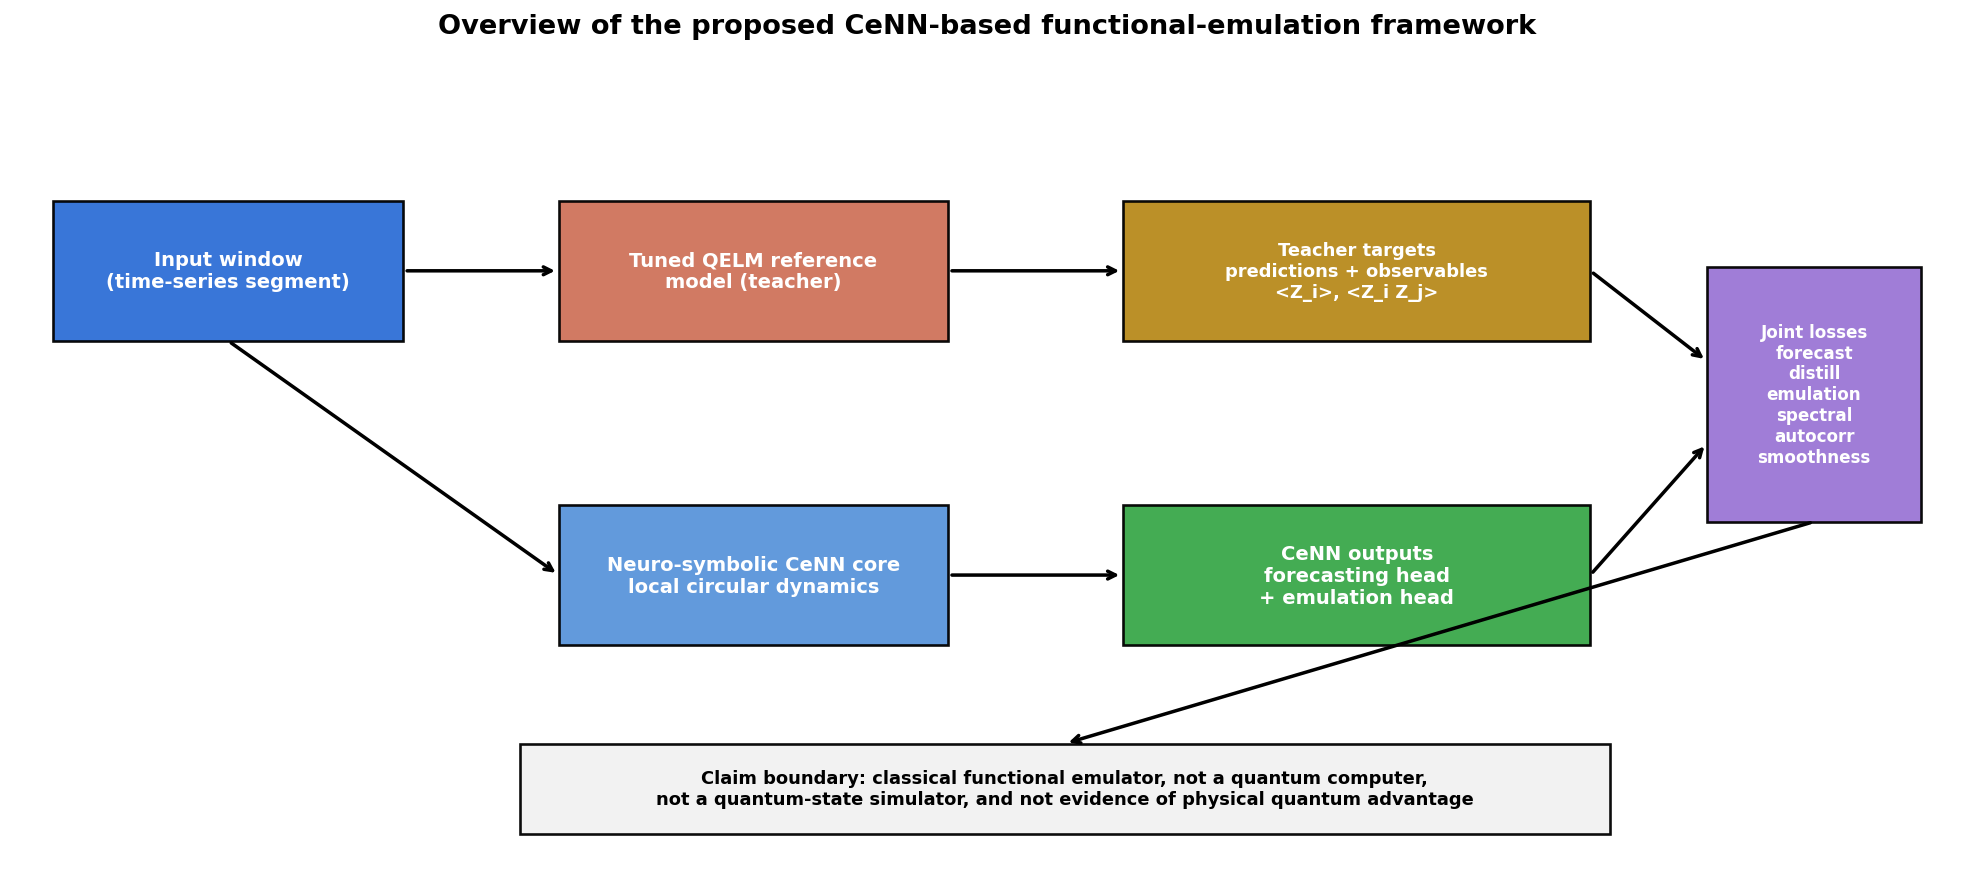

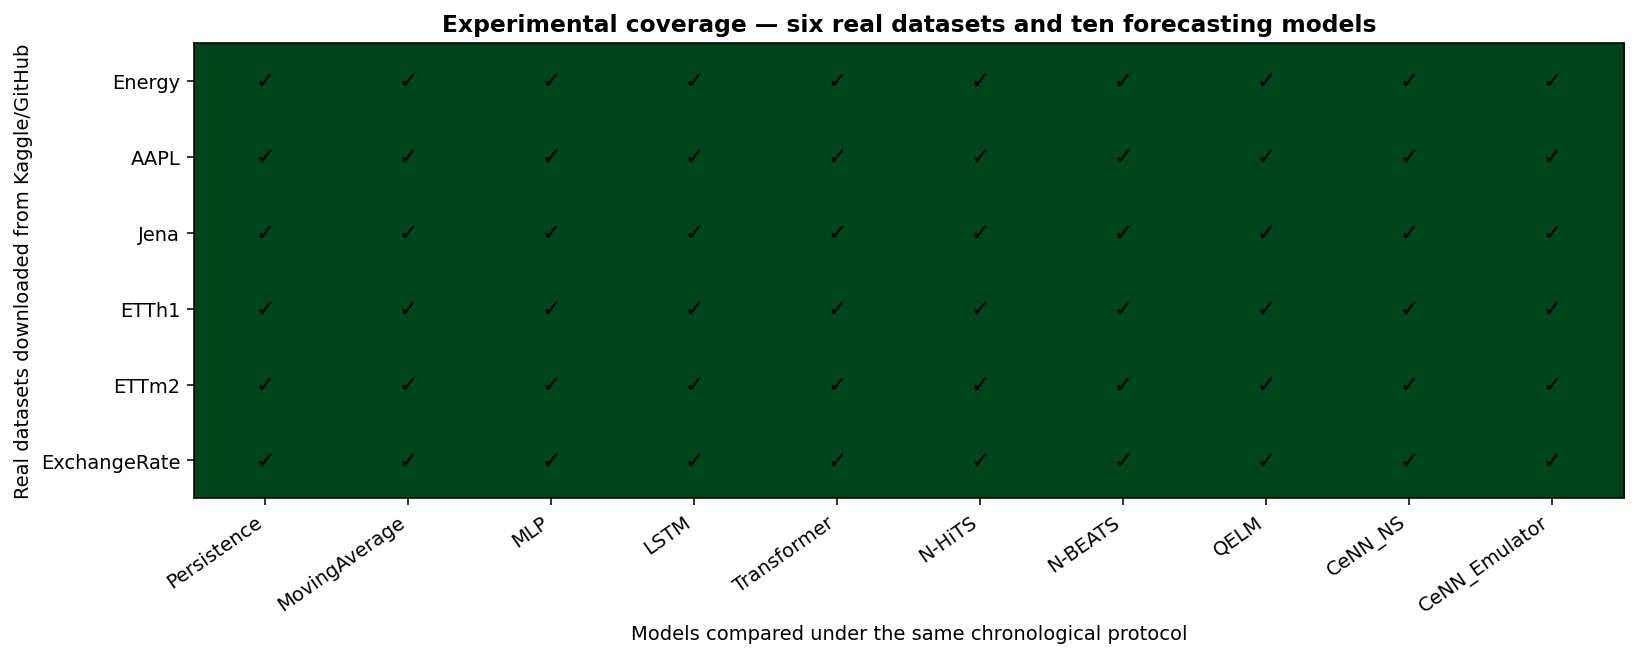

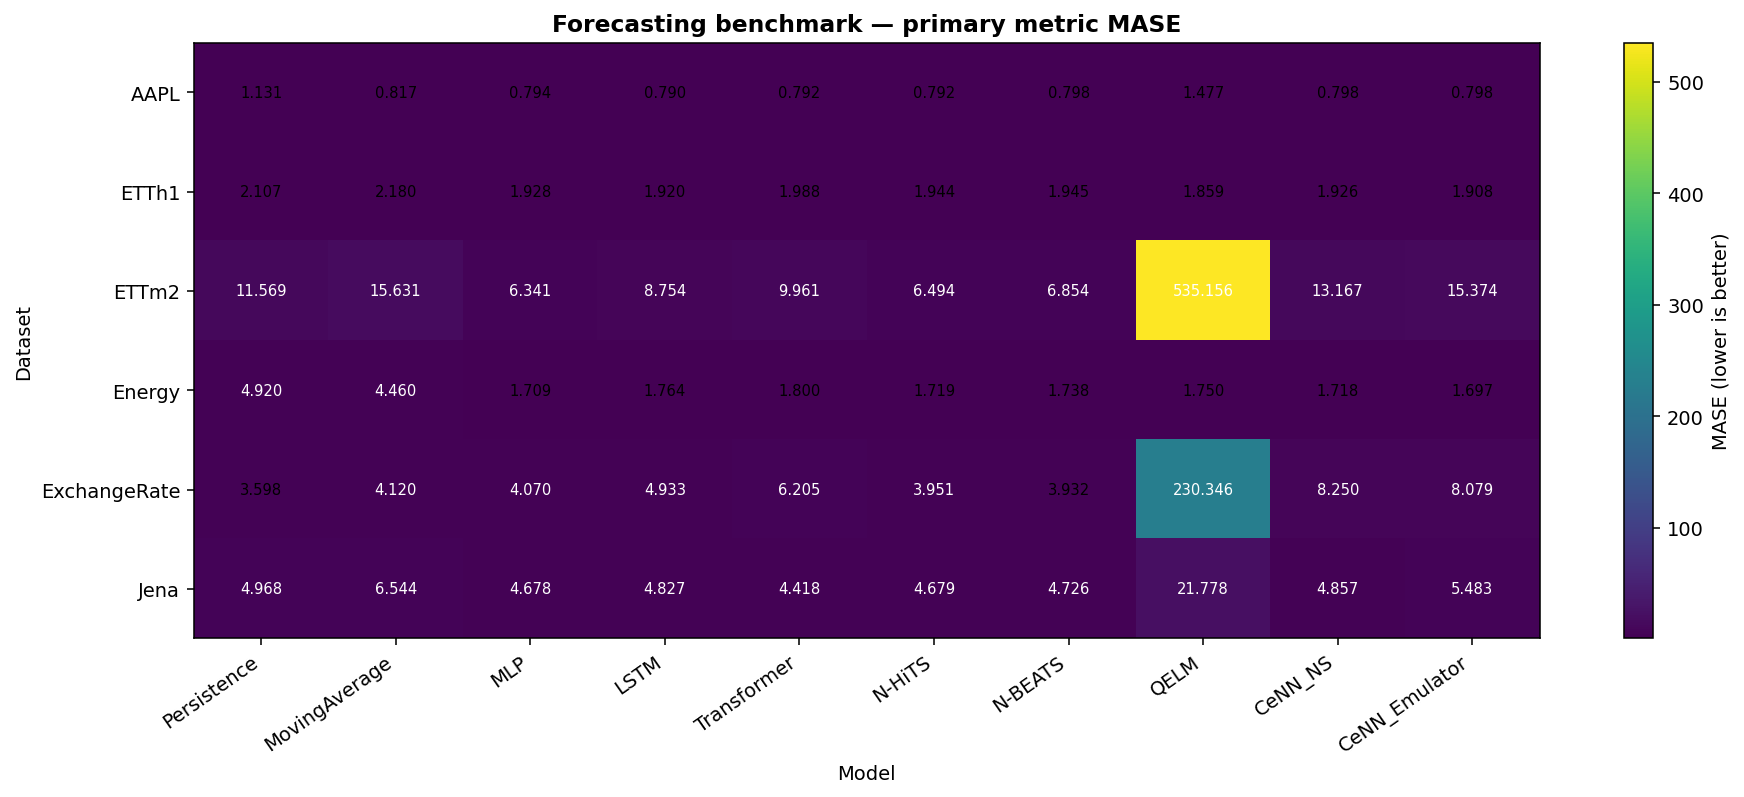

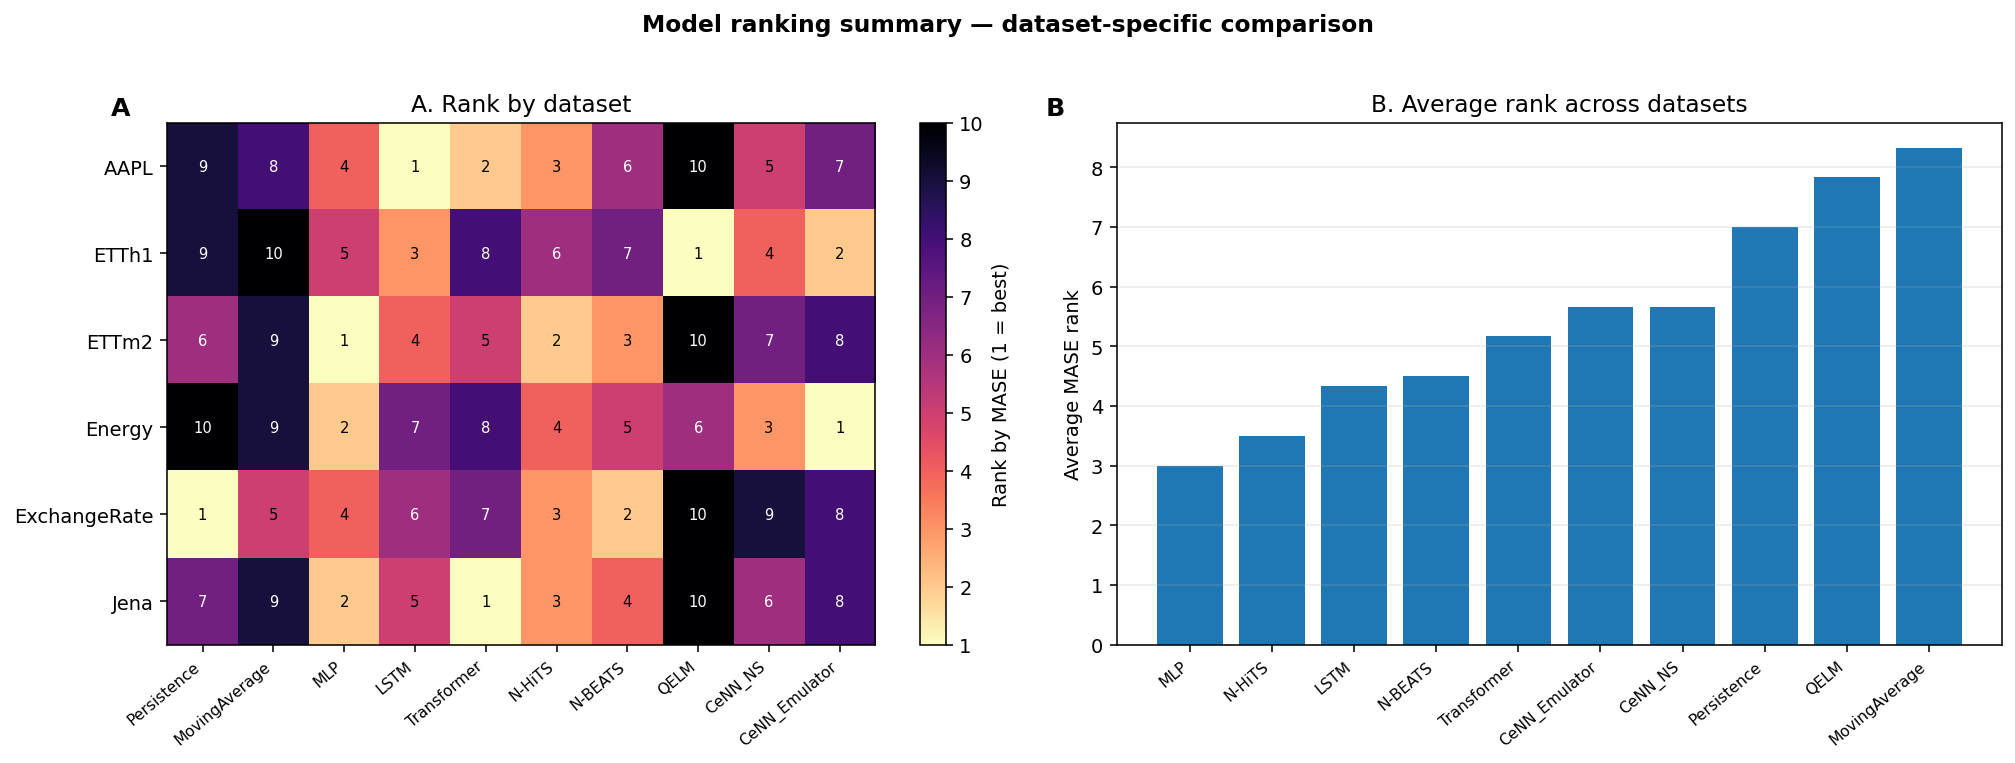

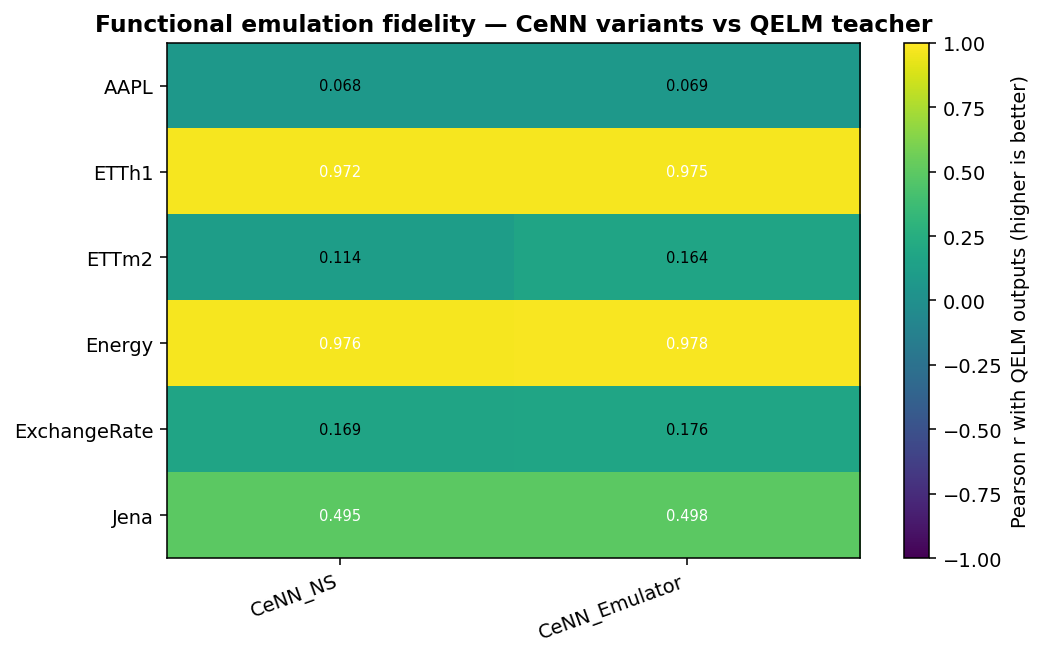

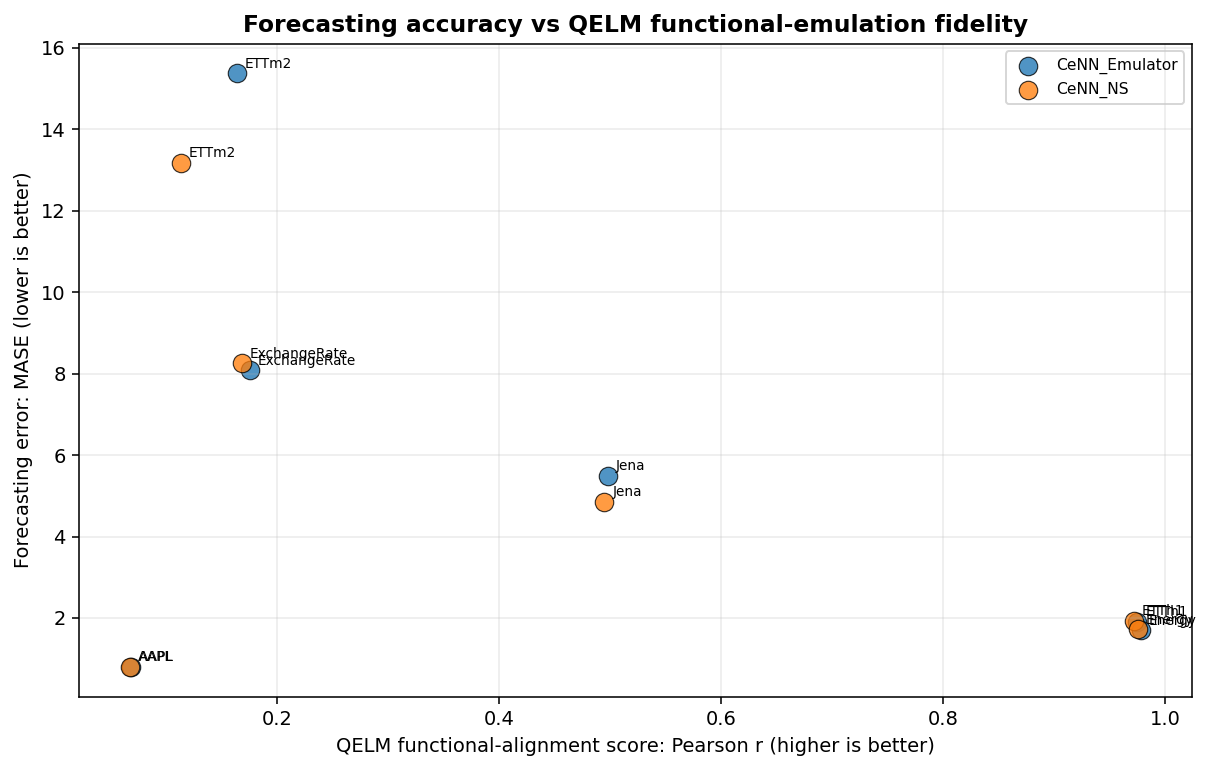

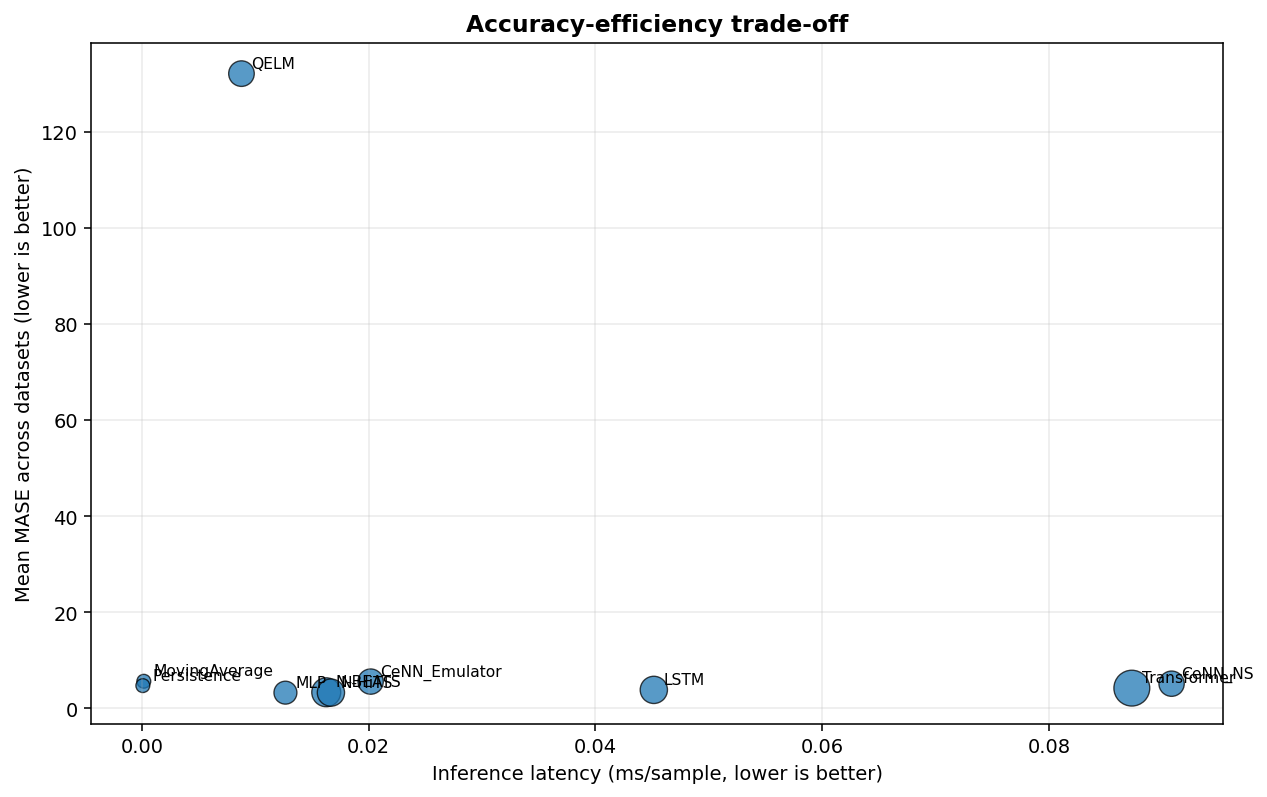

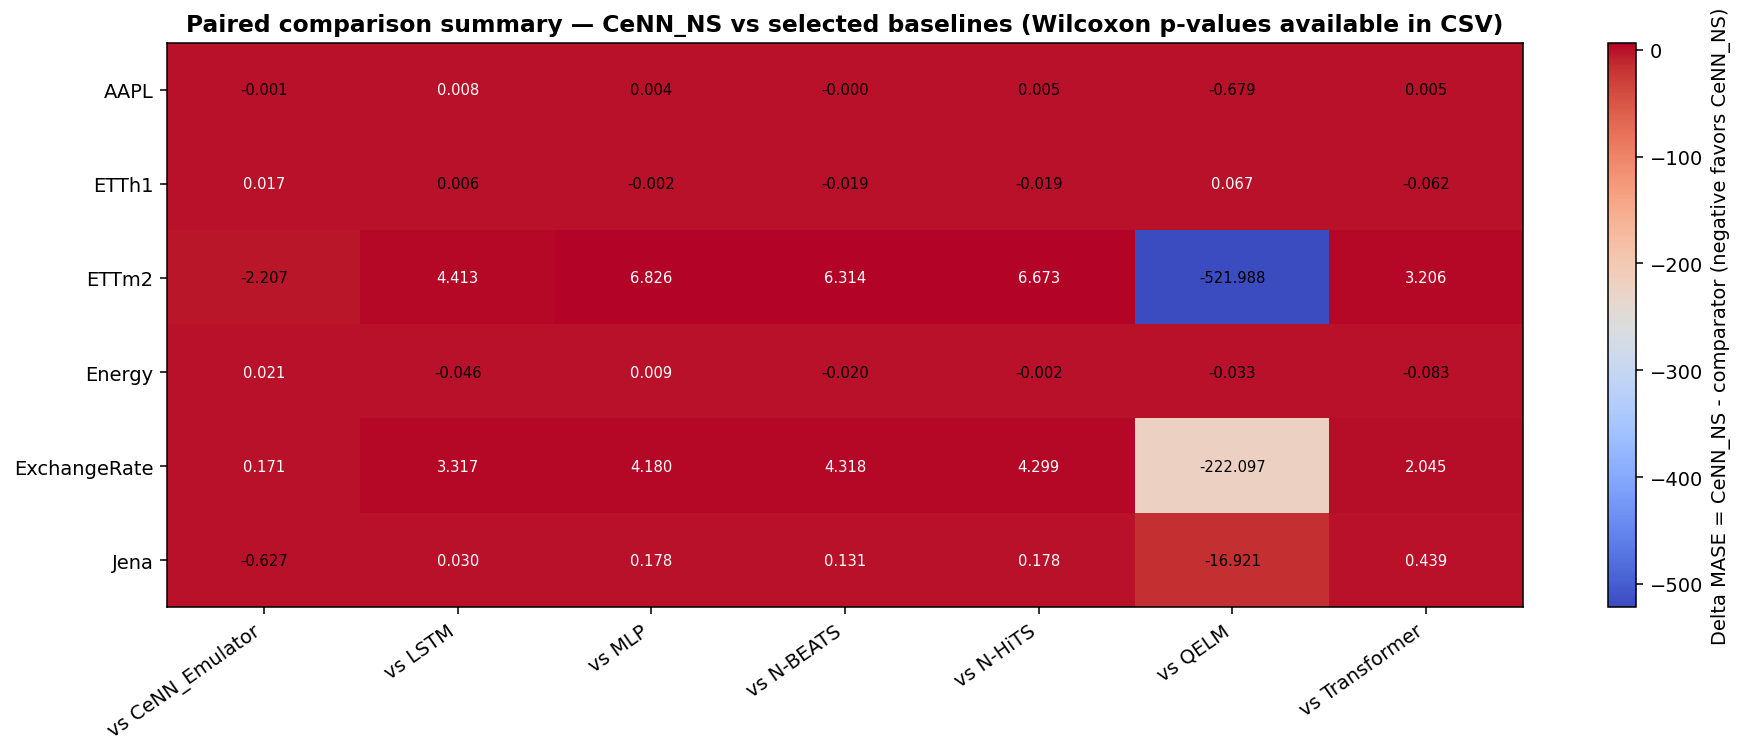

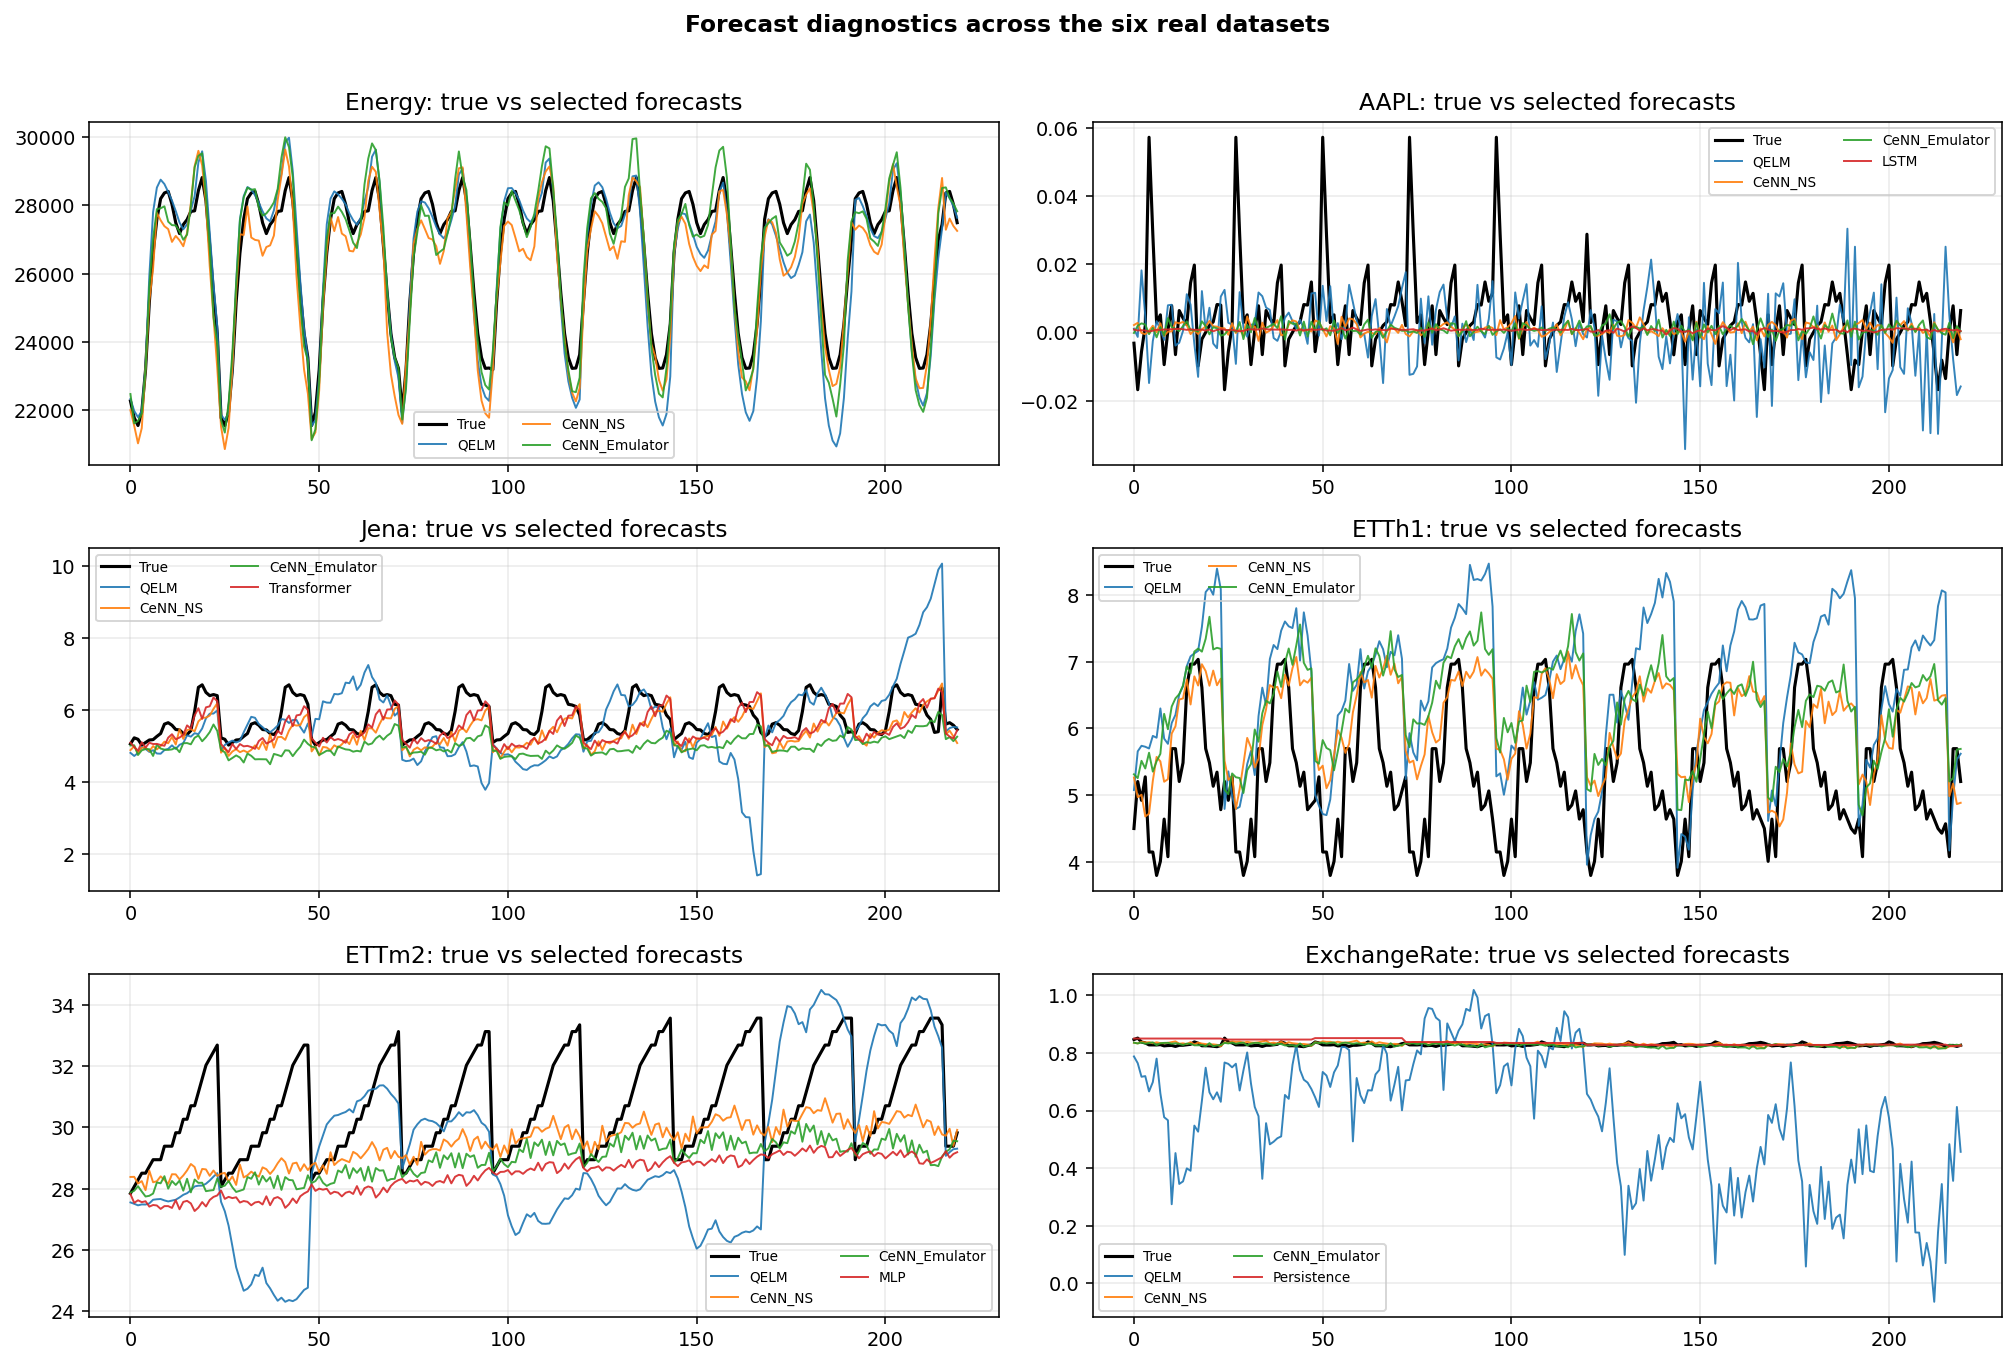

Core article figures written to: /kaggle/working/outputs/full_run/figures/core_article
Supplementary diagnostic figures written to: /kaggle/working/outputs/full_run/figures/supplementary_diagnostics
Figure manifest written to: /kaggle/working/outputs/full_run/article_figure_manifest.csv
Displayed figures are intentionally limited to the external researcher-facing evidence needed for the article.


In [13]:
# ================================================================
# CELL 12 - Core article figures for public reproducibility
# ================================================================

# This cell intentionally displays only the core figures used to interpret the architecture and results.
# Additional diagnostic figures are saved as supplementary files but are not displayed by default.

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.facecolor": "none",
    "axes.facecolor": "none",
})

DISPLAY_CORE_FIGURES = True
DISPLAY_SUPPLEMENTARY_DIAGNOSTICS = False

CORE_FIGURE_ROOT = FIGURE_ROOT / "core_article"
SUPP_FIGURE_ROOT = FIGURE_ROOT / "supplementary_diagnostics"
CORE_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
SUPP_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

figure_manifest = []

def safe_filename(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text)).strip("_")

def save_publication_figure(path_without_ext, fig=None, display=True, caption="", article_purpose=""):
    """Save each figure as transparent PNG and PDF and optionally display it in the notebook."""
    if fig is None:
        fig = plt.gcf()
    path_without_ext = Path(path_without_ext)
    path_without_ext.parent.mkdir(parents=True, exist_ok=True)
    try:
        fig.tight_layout()
    except Exception:
        pass
    png_path = path_without_ext.with_suffix(".png")
    pdf_path = path_without_ext.with_suffix(".pdf")
    fig.savefig(png_path, transparent=True, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, transparent=True, bbox_inches="tight")
    figure_manifest.append({
        "figure_file_png": str(png_path),
        "figure_file_pdf": str(pdf_path),
        "caption_draft": caption,
        "article_purpose": article_purpose,
        "displayed_in_notebook": bool(display),
    })
    if display:
        plt.show()
    else:
        plt.close(fig)

def finite_pivot(df, index, columns, values):
    p = df.pivot(index=index, columns=columns, values=values)
    return p.replace([np.inf, -np.inf], np.nan)

def annotate_heatmap(ax, data, fmt=".3f", higher_is_better=False):
    arr = np.asarray(data, dtype=float)
    finite = arr[np.isfinite(arr)]
    if not len(finite):
        return
    threshold = np.nanmedian(finite)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                # Contrast-aware annotation.
                color = "white" if val > threshold else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center", color=color, fontsize=7.6)

def ordered_columns(df, candidates):
    return [m for m in candidates if m in df.columns]

def add_panel_label(ax, label):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes, fontsize=13, fontweight="bold", va="top")

# ----------------------------------------------------------------
# 0) Figure-selection map: why these figures are shown.
# ----------------------------------------------------------------
figure_strategy_rows = [
    ["Hypothesis and scope", "Architecture overview", "Clarifies CeNN as classical functional emulator", "#1, #3, #11, #20"],
    ["Generality and fairness", "Experimental coverage matrix", "Shows 6 real datasets and 10 compared models", "#7, #8, #13, #19"],
    ["Forecasting utility", "MASE benchmark heatmap", "Primary metric across datasets/models", "#4, #7, #8, #19"],
    ["Claim discipline", "Rank and win summary", "Prevents universal-superiority overclaim", "#16, #17, #20, #21"],
    ["Functional emulation", "CeNN/QELM fidelity", "Quantifies teacher alignment", "#2, #3, #11, #12"],
    ["Trade-off", "Forecasting vs emulation", "Separates prediction accuracy from QELM imitation", "#12, #16, #17"],
    ["Scalability", "Accuracy-efficiency", "Relates performance to latency and model size", "#10, #18, #19"],
    ["Statistical reliability", "CeNN_NS paired comparisons", "Shows effect sizes/p-values in full mode", "#4, #13, #21"],
]
figure_strategy_df = pd.DataFrame(
    figure_strategy_rows,
    columns=["External researcher issue group", "Displayed figure", "Role in the manuscript", "External researcher methodological points"]
)
figure_strategy_df.to_csv(OUTPUT_ROOT / "figure_strategy_map.csv", index=False)
display(figure_strategy_df)

# ----------------------------------------------------------------
# 1) Architecture overview. Defends the paper's central claim boundary.
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14.2, 6.4))
ax.axis("off")

def box(ax, x, y, w, h, text, fc, tc="white", fontsize=10):
    rect = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="black", linewidth=1.35, alpha=0.95)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", color=tc, fontsize=fontsize, weight="bold")

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.8, color="black"))

# Input and teacher branch.
box(ax, 0.02, 0.64, 0.18, 0.17, "Input window\n(time-series segment)", "#2f6fd6")
box(ax, 0.28, 0.64, 0.20, 0.17, "Tuned QELM reference\nmodel (teacher)", "#cf735b")
box(ax, 0.57, 0.64, 0.24, 0.17, "Teacher targets\npredictions + observables\n<Z_i>, <Z_i Z_j>", "#b88b1d", fontsize=9.2)

# CeNN branch.
box(ax, 0.28, 0.27, 0.20, 0.17, "Neuro-symbolic CeNN core\nlocal circular dynamics", "#5a95db")
box(ax, 0.57, 0.27, 0.24, 0.17, "CeNN outputs\nforecasting head\n+ emulation head", "#3ba84a")

# Objective and claim boundary.
box(ax, 0.87, 0.42, 0.11, 0.31, "Joint losses\nforecast\ndistill\nemulation\nspectral\nautocorr\nsmoothness", "#9b77d5", fontsize=8.6)
box(ax, 0.26, 0.04, 0.56, 0.11,
    "Claim boundary: classical functional emulator, not a quantum computer,\nnot a quantum-state simulator, and not evidence of physical quantum advantage",
    "#f2f2f2", tc="black", fontsize=9.2)

arrow(ax, 0.20, 0.725, 0.28, 0.725); arrow(ax, 0.48, 0.725, 0.57, 0.725)
arrow(ax, 0.11, 0.64, 0.28, 0.355); arrow(ax, 0.48, 0.355, 0.57, 0.355)
arrow(ax, 0.81, 0.725, 0.87, 0.615); arrow(ax, 0.81, 0.355, 0.87, 0.515)
arrow(ax, 0.925, 0.42, 0.54, 0.15)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Overview of the proposed CeNN-based functional-emulation framework", fontsize=14, weight="bold")
save_publication_figure(
    CORE_FIGURE_ROOT / "01_architecture_overview",
    fig,
    display=DISPLAY_CORE_FIGURES,
    caption="Overview of the proposed CeNN-based functional-emulation framework. A tuned QELM reference model provides prediction targets and observable-level features, while the CeNN produces forecasting and emulation outputs. The framework is evaluated as a classical functional emulator, not as a quantum-state simulator.",
    article_purpose="architecture scope and functional-emulation boundary"
)

# ----------------------------------------------------------------
# 2) Experimental coverage matrix. Defends dataset/model breadth.
# ----------------------------------------------------------------
coverage = pd.DataFrame(1, index=DATASET_NAMES, columns=MODEL_ORDER)
fig, ax = plt.subplots(figsize=(11.8, 4.8))
im = ax.imshow(coverage.values, aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns, rotation=35, ha="right")
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        ax.text(j, i, "✓", ha="center", va="center", fontsize=12, weight="bold")
ax.set_title("Experimental coverage — six real datasets and ten forecasting models", weight="bold")
ax.set_xlabel("Models compared under the same chronological protocol")
ax.set_ylabel("Real datasets downloaded from Kaggle/GitHub")
save_publication_figure(
    CORE_FIGURE_ROOT / "02_experimental_coverage_matrix",
    fig,
    display=DISPLAY_CORE_FIGURES,
    caption="Experimental coverage matrix. The revised benchmark evaluates ten models on six real datasets using the same leakage-safe chronological protocol.",
    article_purpose="benchmark coverage, baselines, and reproducibility"
)

# ----------------------------------------------------------------
# 3) Primary forecasting benchmark: MASE heatmap.
# ----------------------------------------------------------------
heat = finite_pivot(rank_df, "dataset", "model", "MASE")
heat = heat[ordered_columns(heat, MODEL_ORDER)]
fig, ax = plt.subplots(figsize=(13.6, 5.8))
im = ax.imshow(heat.values.astype(float), aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax, label="MASE (lower is better)")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
annotate_heatmap(ax, heat.values, ".3f")
ax.set_title("Forecasting benchmark — primary metric MASE", weight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Dataset")
save_publication_figure(
    CORE_FIGURE_ROOT / "03_benchmark_mase_heatmap",
    fig,
    display=DISPLAY_CORE_FIGURES,
    caption="Forecasting benchmark across six real datasets. MASE is used as the primary scale-free forecasting metric; lower values indicate better performance.",
    article_purpose="forecasting performance across datasets and baselines"
)

# ----------------------------------------------------------------
# 4) Rank and win summary. Defends claim discipline.
# ----------------------------------------------------------------
rank_heat = finite_pivot(rank_df, "dataset", "model", "rank_MASE")
rank_heat = rank_heat[ordered_columns(rank_heat, MODEL_ORDER)]
avg_rank = rank_df.groupby("model", as_index=False)["rank_MASE"].mean().sort_values("rank_MASE")
best_by_dataset = rank_df.loc[rank_df.groupby("dataset")["MASE"].idxmin()].copy()
win_counts = best_by_dataset["model"].value_counts().reindex(MODEL_ORDER, fill_value=0).reset_index()
win_counts.columns = ["model", "wins"]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.3))
im = axes[0].imshow(rank_heat.values.astype(float), aspect="auto", cmap="magma_r", vmin=1, vmax=len(MODEL_ORDER))
fig.colorbar(im, ax=axes[0], label="Rank by MASE (1 = best)")
axes[0].set_xticks(range(len(rank_heat.columns)))
axes[0].set_xticklabels(rank_heat.columns, rotation=40, ha="right", fontsize=8)
axes[0].set_yticks(range(len(rank_heat.index)))
axes[0].set_yticklabels(rank_heat.index)
annotate_heatmap(axes[0], rank_heat.values, ".0f")
axes[0].set_title("A. Rank by dataset")
add_panel_label(axes[0], "A")

axes[1].bar(avg_rank["model"], avg_rank["rank_MASE"])
axes[1].set_xticks(range(len(avg_rank)))
axes[1].set_xticklabels(avg_rank["model"], rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("Average MASE rank")
axes[1].set_title("B. Average rank across datasets")
axes[1].grid(axis="y", alpha=0.25)
add_panel_label(axes[1], "B")
fig.suptitle("Model ranking summary — dataset-specific comparison", y=1.02, weight="bold")
save_publication_figure(
    CORE_FIGURE_ROOT / "04_rank_summary_mase",
    fig,
    display=DISPLAY_CORE_FIGURES,
    caption="Ranking summary based on MASE. This figure identifies dataset-specific strengths without implying universal superiority of any single model.",
    article_purpose="dataset-specific ranking and cautious interpretation"
)

# ----------------------------------------------------------------
# 5) Functional emulation fidelity against QELM.
# ----------------------------------------------------------------
if len(emulation_df):
    # Robust aggregation: not all runs necessarily export observable-level diagnostics.
    # Earlier versions used the lowercase key ``observable_mse``; the current metric key is
    # ``observable_MSE``. This block accepts either form and skips the observable summary
    # if no such column exists, preventing KeyError in public runs.
    agg_spec = {
        "emul_Pearson_r_mean": ("emul_Pearson_r", "mean"),
        "emul_Pearson_r_std": ("emul_Pearson_r", "std"),
        "emul_JS_distance_mean": ("emul_JS_distance", "mean"),
        "emul_spectral_distance_mean": ("emul_spectral_distance", "mean"),
    }
    if "observable_MSE" in emulation_df.columns:
        agg_spec["observable_MSE_mean"] = ("observable_MSE", "mean")
    elif "observable_mse" in emulation_df.columns:
        agg_spec["observable_MSE_mean"] = ("observable_mse", "mean")

    em_plot = (
        emulation_df.groupby(["dataset", "model"], as_index=False)
        .agg(**agg_spec)
        .replace([np.inf, -np.inf], np.nan)
    )

    p_r = em_plot.pivot(index="dataset", columns="model", values="emul_Pearson_r_mean")
    p_r = p_r[[m for m in ["CeNN_NS", "CeNN_Emulator"] if m in p_r.columns]]
    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    im = ax.imshow(p_r.values.astype(float), aspect="auto", cmap="viridis", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, label="Pearson r with QELM outputs (higher is better)")
    ax.set_xticks(range(len(p_r.columns)))
    ax.set_xticklabels(p_r.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(p_r.index)))
    ax.set_yticklabels(p_r.index)
    annotate_heatmap(ax, p_r.values, ".3f", higher_is_better=True)
    ax.set_title("Functional emulation fidelity — CeNN variants vs QELM teacher", weight="bold")
    save_publication_figure(
        CORE_FIGURE_ROOT / "05_emulation_fidelity_qelm_pearson",
        fig,
        display=DISPLAY_CORE_FIGURES,
        caption="Functional-emulation fidelity measured by Pearson correlation between CeNN outputs and QELM teacher outputs. Higher values indicate stronger functional alignment.",
        article_purpose="functional-emulation fidelity against QELM teacher"
    )
else:
    print("No emulation_df rows available. Functional-emulation fidelity figure skipped.")

# ----------------------------------------------------------------
# 6) Forecasting-vs-emulation trade-off.
# ----------------------------------------------------------------
if len(emulation_df):
    trade_em = emulation_df.groupby(["dataset", "model"], as_index=False).agg(
        emul_Pearson_r=("emul_Pearson_r", "mean"),
        emul_JS_distance=("emul_JS_distance", "mean"),
    )
    mase_model = rank_df[["dataset", "model", "MASE"]].copy()
    trade_em = trade_em.merge(mase_model, on=["dataset", "model"], how="left")
    trade_em = trade_em.replace([np.inf, -np.inf], np.nan)
    trade_em = trade_em[np.isfinite(trade_em["MASE"]) & np.isfinite(trade_em["emul_Pearson_r"])]
    fig, ax = plt.subplots(figsize=(8.8, 5.6))
    if len(trade_em):
        for model in trade_em["model"].unique():
            sub = trade_em[trade_em["model"] == model]
            ax.scatter(sub["emul_Pearson_r"], sub["MASE"], s=90, label=model, alpha=0.78, edgecolors="black", linewidths=0.6)
            for _, r in sub.iterrows():
                ax.annotate(r["dataset"], (r["emul_Pearson_r"], r["MASE"]), xytext=(4, 3), textcoords="offset points", fontsize=7)
    ax.set_xlabel("QELM functional-alignment score: Pearson r (higher is better)")
    ax.set_ylabel("Forecasting error: MASE (lower is better)")
    ax.set_title("Forecasting accuracy vs QELM functional-emulation fidelity", weight="bold")
    ax.grid(alpha=0.25)
    ax.legend(frameon=True)
    save_publication_figure(
        CORE_FIGURE_ROOT / "06_forecasting_emulation_tradeoff",
        fig,
        display=DISPLAY_CORE_FIGURES,
        caption="Forecasting--emulation trade-off. The figure separates direct forecasting accuracy from QELM functional alignment and helps interpret CeNN_NS and CeNN_Emulator as different operating points.",
        article_purpose="forecasting--emulation trade-off"
    )

# ----------------------------------------------------------------
# 7) Accuracy-efficiency trade-off.
# ----------------------------------------------------------------
trade = results_df.groupby("model", as_index=False).agg(
    MASE_mean=("MASE", "mean"),
    MASE_std=("MASE", "std"),
    latency_mean=("inference_ms_per_sample", "mean"),
    param_count_mean=("param_count", "mean"),
).replace([np.inf, -np.inf], np.nan)
trade = trade[np.isfinite(trade["MASE_mean"]) & np.isfinite(trade["latency_mean"])]
fig, ax = plt.subplots(figsize=(9.2, 5.8))
if len(trade):
    sizes = np.sqrt(np.maximum(trade["param_count_mean"].fillna(0).values, 0) + 1)
    sizes = 50 + 290 * sizes / max(sizes.max(), 1)
    ax.scatter(trade["latency_mean"], trade["MASE_mean"], s=sizes, alpha=0.74, edgecolors="black", linewidths=0.7)
    for _, r in trade.iterrows():
        ax.annotate(r["model"], (r["latency_mean"], r["MASE_mean"]), xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("Inference latency (ms/sample, lower is better)")
ax.set_ylabel("Mean MASE across datasets (lower is better)")
ax.set_title("Accuracy-efficiency trade-off", weight="bold")
ax.grid(alpha=0.25)
save_publication_figure(
    CORE_FIGURE_ROOT / "07_accuracy_efficiency_tradeoff",
    fig,
    display=DISPLAY_CORE_FIGURES,
    caption="Accuracy--efficiency trade-off. Bubble size is proportional to parameter count, while the axes summarize mean forecasting error and inference latency.",
    article_purpose="accuracy, latency, and model-size trade-off"
)

# ----------------------------------------------------------------
# 8) Statistical reliability panel: CeNN_NS paired comparisons.
# ----------------------------------------------------------------
stat_for_plot = stat_df.copy() if "stat_df" in globals() else pd.DataFrame()
if len(stat_for_plot):
    # Select comparisons that matter most for the claim: strong neural baselines and QELM/CeNN_Emulator.
    keep_comparisons = [
        "CeNN_NS vs MLP", "CeNN_NS vs LSTM", "CeNN_NS vs Transformer",
        "CeNN_NS vs N-HiTS", "CeNN_NS vs N-BEATS", "CeNN_NS vs QELM", "CeNN_NS vs CeNN_Emulator"
    ]
    sp = stat_for_plot[stat_for_plot["comparison"].isin(keep_comparisons)].copy()
    sp = sp.replace([np.inf, -np.inf], np.nan)
    if len(sp):
        pivot_delta = sp.pivot(index="dataset", columns="comparison", values="MASE_delta_CeNN_minus_other")
        fig, ax = plt.subplots(figsize=(13.5, 5.5))
        im = ax.imshow(pivot_delta.values.astype(float), aspect="auto", cmap="coolwarm")
        fig.colorbar(im, ax=ax, label="Delta MASE = CeNN_NS - comparator (negative favors CeNN_NS)")
        ax.set_xticks(range(len(pivot_delta.columns)))
        ax.set_xticklabels([c.replace("CeNN_NS vs ", "vs ") for c in pivot_delta.columns], rotation=35, ha="right")
        ax.set_yticks(range(len(pivot_delta.index)))
        ax.set_yticklabels(pivot_delta.index)
        annotate_heatmap(ax, pivot_delta.values, ".3f")
        min_pairs = int(sp["n_pairs"].min()) if np.isfinite(sp["n_pairs"]).any() else 0
        suffix = "Wilcoxon p-values available in CSV" if min_pairs >= 3 else "smoke mode: p-values require full mode"
        ax.set_title(f"Paired comparison summary — CeNN_NS vs selected baselines ({suffix})", weight="bold")
        save_publication_figure(
            CORE_FIGURE_ROOT / "08_statistical_comparison_delta_mase",
            fig,
            display=DISPLAY_CORE_FIGURES,
            caption="Paired comparison summary. Negative delta means CeNN_NS has lower MASE than the comparator. Statistical p-values and effect sizes are exported in the CSV files; full significance testing requires full mode with multiple seeds.",
            article_purpose="statistical comparison and run-level reliability"
        )

# ----------------------------------------------------------------
# 9) Compact prediction panel across datasets.
# ----------------------------------------------------------------
# This figure is displayed because it helps visually inspect the forecasting behavior, but it is
# still secondary to the metric tables and heatmaps.
if "prediction_store" in globals() and len(prediction_store):
    seed = CFG["seeds"][0]
    n_cols = 2
    n_rows = int(np.ceil(len(DATASET_NAMES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14.5, 3.2 * n_rows), squeeze=False)
    for idx, ds_name in enumerate(DATASET_NAMES):
        ax = axes[idx // n_cols, idx % n_cols]
        d = PREPARED[ds_name]
        true = np.asarray(d.test_y_raw).reshape(-1)
        n_show = min(220, len(true))
        # Dataset-specific best model by MASE, plus QELM and the two CeNN variants.
        sub_rank = rank_df[rank_df["dataset"] == ds_name].sort_values("MASE")
        best_model = sub_rank.iloc[0]["model"] if len(sub_rank) else "CeNN_NS"
        models_to_plot = list(dict.fromkeys(["QELM", "CeNN_NS", "CeNN_Emulator", best_model]))
        models_to_plot = [m for m in models_to_plot if (ds_name, m, seed) in prediction_store]
        ax.plot(true[:n_show], label="True", linewidth=1.6, color="black")
        for m in models_to_plot:
            pred = np.asarray(prediction_store[(ds_name, m, seed)]).reshape(-1)[:n_show]
            ax.plot(pred, label=m, linewidth=1.0, alpha=0.90)
        ax.set_title(f"{ds_name}: true vs selected forecasts")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7, ncol=2)
    # Hide unused axes.
    for j in range(len(DATASET_NAMES), n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")
    fig.suptitle("Forecast diagnostics across the six real datasets", y=1.01, weight="bold")
    save_publication_figure(
        CORE_FIGURE_ROOT / "09_prediction_diagnostics_panel",
        fig,
        display=DISPLAY_CORE_FIGURES,
        caption="Forecast diagnostics across the six real datasets. The panel compares the true test sequence with QELM, CeNN_NS, CeNN_Emulator, and the best model by MASE for each dataset.",
        article_purpose="public article figure"
    )

# ----------------------------------------------------------------
# Supplementary diagnostics: saved but not displayed by default.
# ----------------------------------------------------------------
key_metrics = ["MASE", "RMSE", "MAE", "R2", "sMAPE", "WAPE", "DirectionalAccuracy"]
available_key_metrics = [m for m in key_metrics if m in results_df.columns]
metric_summary = results_df.groupby(["dataset", "model"], as_index=False)[available_key_metrics].mean()
for metric in available_key_metrics:
    p = finite_pivot(metric_summary, "dataset", "model", metric)
    p = p[ordered_columns(p, MODEL_ORDER)]
    fig, ax = plt.subplots(figsize=(13.0, 5.4))
    cmap = "viridis" if metric not in ["R2", "DirectionalAccuracy"] else "viridis"
    im = ax.imshow(p.values.astype(float), aspect="auto", cmap=cmap)
    fig.colorbar(im, ax=ax, label=metric)
    ax.set_xticks(range(len(p.columns)))
    ax.set_xticklabels(p.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(p.index)))
    ax.set_yticklabels(p.index)
    annotate_heatmap(ax, p.values, ".3f", higher_is_better=metric in ["R2", "Pearson", "Spearman", "DirectionalAccuracy"])
    better = "higher is better" if metric in ["R2", "Pearson", "Spearman", "DirectionalAccuracy"] else "lower is better"
    ax.set_title(f"Supplementary metric heatmap — {metric} ({better})", weight="bold")
    save_publication_figure(
        SUPP_FIGURE_ROOT / f"metric_heatmap_{safe_filename(metric)}",
        fig,
        display=DISPLAY_SUPPLEMENTARY_DIAGNOSTICS,
        caption=f"Supplementary benchmark heatmap for {metric}.",
        article_purpose="supplementary metric diagnostics"
    )

# Absolute-error distributions per dataset are useful for supplementary material only.
selected_models_for_errors = ["Persistence", "MLP", "LSTM", "Transformer", "N-HiTS", "N-BEATS", "QELM", "CeNN_NS", "CeNN_Emulator"]
if "prediction_store" in globals() and len(prediction_store):
    for ds_name in DATASET_NAMES:
        d = PREPARED[ds_name]
        seed = CFG["seeds"][0]
        true = np.asarray(d.test_y_raw).reshape(-1)
        box_data, labels = [], []
        for m in selected_models_for_errors:
            key = (ds_name, m, seed)
            if key in prediction_store:
                pred = np.asarray(prediction_store[key]).reshape(-1)
                err = np.abs(true - pred)
                err = err[np.isfinite(err)]
                if len(err):
                    upper = np.nanpercentile(err, 99)
                    box_data.append(err[err <= upper])
                    labels.append(m)
        if box_data:
            fig, ax = plt.subplots(figsize=(11.0, 4.5))
            ax.boxplot(box_data, labels=labels, showfliers=False)
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels, rotation=35, ha="right")
            ax.set_ylabel("Absolute error (original scale)")
            ax.set_title(f"Supplementary diagnostic — {ds_name} absolute-error distribution", weight="bold")
            ax.grid(axis="y", alpha=0.25)
            save_publication_figure(
                SUPP_FIGURE_ROOT / f"absolute_error_distribution_{safe_filename(ds_name)}",
                fig,
                display=DISPLAY_SUPPLEMENTARY_DIAGNOSTICS,
                caption=f"Supplementary absolute-error distribution for {ds_name}.",
                article_purpose="supplementary error-distribution diagnostics"
            )

figure_manifest_df = pd.DataFrame(figure_manifest)
figure_manifest_df.to_csv(OUTPUT_ROOT / "article_figure_manifest.csv", index=False)

print("Core article figures written to:", CORE_FIGURE_ROOT)
print("Supplementary diagnostic figures written to:", SUPP_FIGURE_ROOT)
print("Figure manifest written to:", OUTPUT_ROOT / "article_figure_manifest.csv")
print("Displayed figures are intentionally limited to the external researcher-facing evidence needed for the article.")


In [14]:
# ================================================================
# CELL 13 - Metadata export and final integrity checks
# ================================================================
import dataclasses

def make_json_safe(obj):
    """Recursively convert Python/NumPy/Pandas objects to JSON-safe objects."""
    if obj is None:
        return None
    if isinstance(obj, (str, bool, int, float)):
        if isinstance(obj, float) and not np.isfinite(obj):
            return None
        return obj
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, (np.ndarray,)):
        # Metadata should not contain large arrays. Store only compact array descriptors.
        arr = np.asarray(obj)
        return {
            "array_shape": list(arr.shape),
            "array_dtype": str(arr.dtype),
            "array_min": float(np.nanmin(arr)) if arr.size else None,
            "array_max": float(np.nanmax(arr)) if arr.size else None,
            "array_mean": float(np.nanmean(arr)) if arr.size else None,
        }
    if isinstance(obj, (pd.Series, pd.Index)):
        return make_json_safe(obj.to_list())
    if isinstance(obj, pd.DataFrame):
        return make_json_safe(obj.to_dict(orient="records"))
    if dataclasses.is_dataclass(obj):
        return make_json_safe(dataclasses.asdict(obj))
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [make_json_safe(x) for x in obj]
    return str(obj)

dataset_manifest_records = []
for ds in DATASETS:
    dataset_manifest_records.append({
        "name": ds.name,
        "raw_length": int(ds.raw_length),
        "used_length": int(ds.used_length),
        "target_col": str(ds.target_col),
        "source_file": str(ds.source_file),
        "transform": str(ds.transform),
    })

metadata = {
    "run_mode": RUN_MODE,
    "window": WINDOW,
    "horizon": HORIZON,
    "split_ratios": SPLIT_RATIOS,
    "profile": CFG,
    "datasets": dataset_manifest_records,
    "models": MODEL_ORDER,
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "no_synthetic_data": True,
    "dataset_policy": "real datasets only; Kaggle/GitHub download or explicit failure",
    "primary_metric": "MASE",
    "supporting_metrics": list(globals().get("metric_cols", [])),
    "outputs": {
        "benchmark": str(OUTPUT_ROOT / "benchmark_full.csv"),
        "summary": str(OUTPUT_ROOT / "summary_full.csv"),
        "rankings": str(OUTPUT_ROOT / "rankings_mase_full.csv"),
        "statistical_comparison": str(OUTPUT_ROOT / "statistical_comparison_full.csv"),
        "emulation_fidelity": str(OUTPUT_ROOT / "emulation_fidelity_full.csv"),
        "dataset_manifest": str(OUTPUT_ROOT / "dataset_manifest.csv"),
        "figures": str(FIGURE_ROOT),
        "core_article_figures": str(FIGURE_ROOT / "core_article"),
        "supplementary_diagnostics": str(FIGURE_ROOT / "supplementary_diagnostics"),
        "article_figure_manifest": str(OUTPUT_ROOT / "article_figure_manifest.csv"),
    },
}

with open(OUTPUT_ROOT / "metadata_full.json", "w", encoding="utf-8") as f:
    json.dump(make_json_safe(metadata), f, indent=2, ensure_ascii=False)

# Sanity checks.
expected = set(DATASET_NAMES)
seen = set(results_df["dataset"].unique())
missing = expected - seen
if missing:
    raise RuntimeError(f"Missing datasets in results: {missing}")

for ds_name in DATASET_NAMES:
    got_models = set(results_df.loc[results_df["dataset"] == ds_name, "model"].unique())
    missing_models = set(MODEL_ORDER) - got_models
    if missing_models:
        raise RuntimeError(f"Dataset {ds_name} missing models: {missing_models}")

print("All integrity checks passed.")
print("Output files:")
for p in sorted(OUTPUT_ROOT.glob("*.csv")):
    print(" -", p.name)
print(" - metadata_full.json")
print("Figures:")
for p in sorted(FIGURE_ROOT.rglob("*.png")):
    print(" -", p.relative_to(FIGURE_ROOT))


All integrity checks passed.
Output files:
 - article_figure_manifest.csv
 - benchmark_full.csv
 - dataset_manifest.csv
 - emulation_fidelity_full.csv
 - emulation_summary_full.csv
 - figure_strategy_map.csv
 - rankings_mase_full.csv
 - statistical_comparison_full.csv
 - summary_full.csv
 - metadata_full.json
Figures:
 - core_article/01_architecture_overview.png
 - core_article/02_experimental_coverage_matrix.png
 - core_article/03_benchmark_mase_heatmap.png
 - core_article/04_rank_summary_mase.png
 - core_article/05_emulation_fidelity_qelm_pearson.png
 - core_article/06_forecasting_emulation_tradeoff.png
 - core_article/07_accuracy_efficiency_tradeoff.png
 - core_article/08_statistical_comparison_delta_mase.png
 - core_article/09_prediction_diagnostics_panel.png
 - supplementary_diagnostics/absolute_error_distribution_AAPL.png
 - supplementary_diagnostics/absolute_error_distribution_ETTh1.png
 - supplementary_diagnostics/absolute_error_distribution_ETTm2.png
 - supplementary_diagnosti

## 5. Interpretation discipline

Use the results carefully:

1. The strongest model should be identified **per dataset and per metric**, not globally.
2. If CeNN_NS or CeNN_Emulator is not the best forecaster, report that honestly.
3. Emulation fidelity and forecasting accuracy are different objectives; a model can align well with QELM without being the best forecaster.
4. Any claim of computational scalability must refer to the classical CeNN architecture and measured latency/parameter count, not to physical quantum advantage.
5. The notebook is a public reproducibility artifact: it documents data sources, preprocessing, models, seeds, metrics, statistical comparisons, figures, and generated outputs without including editorial-response material.
